# Gold Price Direction Prediction

### Cross-Market Feature Engineering and Time-Series Classification

This project investigates whether the direction of the next gold trading session can be predicted using historical gold-market data, technical indicators, price-action features, and cross-market information from oil, the S&P 500, Bitcoin, USD/JPY, and the US Dollar Index.

The project compares classical machine-learning and deep-learning models, including Logistic Regression, Random Forest, LSTM, CNN-LSTM, and an attention-based architecture. Particular emphasis is placed on feature engineering, chronological validation, feature ablation, regularization, and out-of-sample evaluation.

The final model is selected based on empirical validation rather than model complexity.

In [ ]:
%pip install -q ta

import random
from dataclasses import dataclass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from ta.momentum import RSIIndicator
from ta.trend import MACD, SMAIndicator, EMAIndicator

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from pathlib import Path
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    roc_curve,
    precision_recall_curve,
    average_precision_score
)

from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Input,
    LSTM,
    Dense,
    Dropout,
    Conv1D,
    MaxPooling1D,
    MultiHeadAttention,
    GlobalAveragePooling1D,
    Add,
    LayerNormalization
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau
)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
drive_data_dir = Path("/content/drive/MyDrive/Gold")
local_data_dir = Path("data")

DATA_DIR = (
    drive_data_dir
    if drive_data_dir.exists()
    else local_data_dir
)

print("Data directory:", DATA_DIR)

Data directory: /content/drive/MyDrive/Gold


## 1. Experiment Configuration and Reproducibility

This section stores the main experiment settings in one place and fixes the random seed so that experiments are easier to reproduce.

In [ ]:
from dataclasses import dataclass
import random

@dataclass
class Config:
    seed: int = 42

    # Time-series settings
    window_size: int = 100

    # Dataset split
    train_ratio: float = 0.70
    val_ratio: float = 0.15
    test_ratio: float = 0.15

    # Training settings
    batch_size: int = 32
    epochs: int = 100
    learning_rate: float = 1e-3


cfg = Config()

# Make experiments reproducible
random.seed(cfg.seed)
np.random.seed(cfg.seed)
tf.random.set_seed(cfg.seed)

print(cfg)

Config(seed=42, window_size=100, train_ratio=0.7, val_ratio=0.15, test_ratio=0.15, batch_size=32, epochs=100, learning_rate=0.001)


## 2. Financial Data Cleaning Utilities

This section defines reusable functions for converting financial values such as 214.52K or 1.3M into correct numeric values.

In [ ]:
def parse_financial_number(value):
    """
    Convert financial text values into numeric values.

    Examples:
    214.52K -> 214520
    1.5M    -> 1500000
    2.1B    -> 2100000000
    """

    if pd.isna(value):
        return np.nan

    value = str(value).strip().replace(",", "")

    if value in {"", "-", "nan"}:
        return np.nan

    multiplier = 1

    if value.endswith("K"):
        multiplier = 1_000
        value = value[:-1]

    elif value.endswith("M"):
        multiplier = 1_000_000
        value = value[:-1]

    elif value.endswith("B"):
        multiplier = 1_000_000_000
        value = value[:-1]

    try:
        return float(value) * multiplier

    except ValueError:
        return np.nan

In [ ]:
print(parse_financial_number("214.52K"))
print(parse_financial_number("1.5M"))
print(parse_financial_number("2.1B"))
print(parse_financial_number("2,744.65"))

214520.0
1500000.0
2100000000.0
2744.65


In [ ]:
def clean_market_dataframe(df, dayfirst=False):
    """
    Clean a financial-market dataframe.

    - Converts Date into datetime
    - Converts financial text values into numbers
    - Removes Change %
    - Sorts data from oldest to newest
    """

    df = df.copy()

    # Convert Date
    df["Date"] = pd.to_datetime(
        df["Date"],
        errors="coerce",
        dayfirst=dayfirst
    )

    # Convert financial columns
    numeric_columns = [
        "Price",
        "Open",
        "High",
        "Low",
        "Vol."
    ]

    for col in numeric_columns:
        if col in df.columns:
            df[col] = df[col].apply(
                parse_financial_number
            )

    # Remove unnecessary column
    df = df.drop(
        columns=["Change %"],
        errors="ignore"
    )

    # Remove rows with invalid dates
    df = df.dropna(subset=["Date"])

    # Sort from oldest to newest
    df = (
        df
        .sort_values("Date")
        .reset_index(drop=True)
    )

    return df

In [ ]:
import pandas as pd

df_Gold = pd.read_csv(
    DATA_DIR / "Gold Futures.csv"
)

df_Gold.head(5)

,Date,Price,Open,High,Low,Vol.,Change %
0,10/24/2024,"2,744.65","2,733.60","2,744.95","2,730.60",NaN,0.56%
1,10/23/2024,"2,729.40","2,762.60","2,772.60","2,722.10",214.52K,-1.10%
2,10/22/2024,"2,759.80","2,734.70","2,763.30","2,733.50",173.70K,0.76%
3,10/21/2024,"2,738.90","2,736.30","2,755.40","2,728.50",210.45K,0.33%
4,10/18/2024,"2,730.00","2,707.80","2,737.80","2,707.30",178.96K,0.83%


In [ ]:
gold_numeric_columns = [
    "Price",
    "Open",
    "High",
    "Low",
    "Vol."
]

for col in gold_numeric_columns:
    df_Gold[col] = df_Gold[col].apply(parse_financial_number)

df_Gold.head()

,Date,Price,Open,High,Low,Vol.,Change %
0,10/24/2024,2744.65,2733.6,2744.95,2730.6,NaN,0.56%
1,10/23/2024,2729.40,2762.6,2772.60,2722.1,214520.0,-1.10%
2,10/22/2024,2759.80,2734.7,2763.30,2733.5,173700.0,0.76%
3,10/21/2024,2738.90,2736.3,2755.40,2728.5,210450.0,0.33%
4,10/18/2024,2730.00,2707.8,2737.80,2707.3,178960.0,0.83%


In [ ]:
# Convert Date to a real datetime type
df_Gold["Date"] = pd.to_datetime(
    df_Gold["Date"],
    errors="coerce"
)

# Sort from oldest date to newest date
df_Gold = (
    df_Gold
    .sort_values("Date")
    .reset_index(drop=True)
)

df_Gold[["Date", "Price"]].head()

,Date,Price
0,2010-07-19,1181.9
1,2010-07-20,1191.7
2,2010-07-21,1191.8
3,2010-07-22,1195.6
4,2010-07-23,1187.8


In [ ]:
print("Oldest date:", df_Gold["Date"].min())
print("Newest date:", df_Gold["Date"].max())
print("Chronological order:", df_Gold["Date"].is_monotonic_increasing)

Oldest date: 2010-07-19 00:00:00
Newest date: 2024-10-24 00:00:00
Chronological order: True


In [ ]:
df_Oil = pd.read_csv(
    DATA_DIR / "Crude Oil WTI.csv"
)

df_Oil = clean_market_dataframe(
    df_Oil,
    dayfirst=True
)

df_Oil.head()

,Date,Price,Open,High,Low,Vol.
0,2010-07-19,76.54,75.72,77.69,75.50,169550.0
1,2010-07-20,77.44,76.40,77.57,75.65,34220.0
2,2010-07-21,76.56,77.85,78.57,76.20,322410.0
3,2010-07-22,79.30,76.43,79.42,76.16,358820.0
4,2010-07-23,78.98,79.27,79.60,78.40,259740.0


In [ ]:
df_Oil.isnull().sum()

,0
Date,0
Price,0
Open,0
High,0
Low,0
Vol.,132


In [ ]:
df_SP = pd.read_csv(
    DATA_DIR / "S&P 500.csv"
)

df_SP = clean_market_dataframe(
    df_SP,
    dayfirst=False
)

df_SP.head()

,Date,Price,Open,High,Low,Vol.
0,2010-07-19,1071.2,1066.8,1074.7,1061.1,NaN
1,2010-07-20,1083.5,1064.5,1083.9,1056.9,NaN
2,2010-07-21,1069.6,1086.7,1089.0,1065.2,NaN
3,2010-07-22,1093.7,1072.1,1097.5,1072.1,NaN
4,2010-07-23,1102.7,1092.2,1103.7,1087.9,NaN


In [ ]:
df_SP.isnull().sum()

,0
Date,0
Price,0
Open,0
High,0
Low,0
Vol.,3592


In [ ]:
df_Bitcoin = pd.read_csv(
    DATA_DIR / "Bitcoin.csv"
)

df_Bitcoin = clean_market_dataframe(
    df_Bitcoin,
    dayfirst=False
)

df_Bitcoin.head()

,Date,Price,Open,High,Low,Vol.
0,2010-07-19,0.1,0.1,0.1,0.1,570.0
1,2010-07-20,0.1,0.1,0.1,0.1,260.0
2,2010-07-21,0.1,0.1,0.1,0.1,580.0
3,2010-07-22,0.1,0.1,0.1,0.1,2160.0
4,2010-07-23,0.1,0.1,0.1,0.1,2400.0


In [ ]:
df_Bitcoin.isnull().sum()

,0
Date,0
Price,0
Open,0
High,0
Low,0
Vol.,6


In [ ]:
df_USD_JPY = pd.read_csv(
    DATA_DIR / "USD_JPY.csv"
)

df_USD_JPY = clean_market_dataframe(
    df_USD_JPY,
    dayfirst=False
)

df_USD_JPY.head()

,Date,Price,Open,High,Low
0,2010-07-19,86.73,86.68,87.23,86.48
1,2010-07-20,87.50,87.12,87.60,86.69
2,2010-07-21,87.06,87.23,87.49,86.86
3,2010-07-22,86.91,87.00,87.24,86.34
4,2010-07-23,87.44,87.27,87.54,86.73


In [ ]:
df_USD_JPY.isnull().sum()

,0
Date,0
Price,0
Open,0
High,0
Low,0


In [ ]:
df_US_Dollar_Index = pd.read_csv(
    DATA_DIR / "US Dollar Index.csv"
)

df_US_Dollar_Index = clean_market_dataframe(
    df_US_Dollar_Index,
    dayfirst=False
)

df_US_Dollar_Index.head()

,Date,Price,Open,High,Low
0,2010-07-19,82.51,82.72,82.81,82.28
1,2010-07-20,82.75,82.61,83.07,82.18
2,2010-07-21,83.39,82.71,83.45,82.56
3,2010-07-22,82.59,83.25,83.36,82.46
4,2010-07-23,82.46,82.58,83.03,82.21


In [ ]:
datasets = {
    "Gold": df_Gold,
    "Oil": df_Oil,
    "S&P 500": df_SP,
    "Bitcoin": df_Bitcoin,
    "USD/JPY": df_USD_JPY,
    "US Dollar Index": df_US_Dollar_Index,
}

summary = []

for name, data in datasets.items():
    summary.append({
        "Dataset": name,
        "Rows": len(data),
        "Oldest Date": data["Date"].min(),
        "Newest Date": data["Date"].max(),
        "Chronological": data["Date"].is_monotonic_increasing,
        "Missing Values": int(data.isna().sum().sum()),
    })

dataset_summary = pd.DataFrame(summary)

dataset_summary

,Dataset,Rows,Oldest Date,Newest Date,Chronological,Missing Values
0,Gold,3643,2010-07-19,2024-10-24,True,4
1,Oil,3726,2010-07-19,2024-10-24,True,132
2,S&P 500,3592,2010-07-19,2024-10-23,True,3592
3,Bitcoin,5212,2010-07-19,2024-10-24,True,6
4,USD/JPY,3724,2010-07-19,2024-10-24,True,0
5,US Dollar Index,3725,2010-07-19,2024-10-24,True,0


In [ ]:
# Make sure every dataset uses the same Date data type
all_market_datasets = [
    df_Gold,
    df_Oil,
    df_SP,
    df_Bitcoin,
    df_USD_JPY,
    df_US_Dollar_Index,
]

for data in all_market_datasets:
    data["Date"] = pd.to_datetime(
        data["Date"],
        errors="coerce"
    )

print("Gold:", df_Gold["Date"].dtype)
print("Oil:", df_Oil["Date"].dtype)
print("S&P 500:", df_SP["Date"].dtype)
print("Bitcoin:", df_Bitcoin["Date"].dtype)
print("USD/JPY:", df_USD_JPY["Date"].dtype)
print("Dollar Index:", df_US_Dollar_Index["Date"].dtype)

Gold: datetime64[ns]
Oil: datetime64[ns]
S&P 500: datetime64[ns]
Bitcoin: datetime64[ns]
USD/JPY: datetime64[ns]
Dollar Index: datetime64[ns]


## 3. Date-Based Market Alignment

The financial datasets are aligned using their actual trading dates so that each row represents information from the same day across all markets.

In [ ]:
# Keep the price column from each external market
# and give every column a clear name.

market_prices = (
    df_Gold[["Date", "Price"]]
    .rename(columns={"Price": "Gold_Price"})

    .merge(
        df_Oil[["Date", "Price"]]
        .rename(columns={"Price": "Oil_Price"}),
        on="Date",
        how="inner"
    )

    .merge(
        df_SP[["Date", "Price"]]
        .rename(columns={"Price": "SP500_Price"}),
        on="Date",
        how="inner"
    )

    .merge(
        df_Bitcoin[["Date", "Price"]]
        .rename(columns={"Price": "Bitcoin_Price"}),
        on="Date",
        how="inner"
    )

    .merge(
        df_USD_JPY[["Date", "Price"]]
        .rename(columns={"Price": "USDJPY_Price"}),
        on="Date",
        how="inner"
    )

    .merge(
        df_US_Dollar_Index[["Date", "Price"]]
        .rename(columns={"Price": "DollarIndex_Price"}),
        on="Date",
        how="inner"
    )
)

market_prices = market_prices.sort_values("Date").reset_index(drop=True)

market_prices.head()

,Date,Gold_Price,Oil_Price,SP500_Price,Bitcoin_Price,USDJPY_Price,DollarIndex_Price
0,2010-07-19,1181.9,76.54,1071.2,0.1,86.73,82.51
1,2010-07-20,1191.7,77.44,1083.5,0.1,87.50,82.75
2,2010-07-21,1191.8,76.56,1069.6,0.1,87.06,83.39
3,2010-07-22,1195.6,79.30,1093.7,0.1,86.91,82.59
4,2010-07-23,1187.8,78.98,1102.7,0.1,87.44,82.46


In [ ]:
print("Number of aligned rows:", len(market_prices))
print("Oldest date:", market_prices["Date"].min())
print("Newest date:", market_prices["Date"].max())
print("Missing values:", market_prices.isna().sum().sum())

Number of aligned rows: 3552
Oldest date: 2010-07-19 00:00:00
Newest date: 2024-10-23 00:00:00
Missing values: 0


## 4. Feature Engineering

This section creates informative features from historical gold prices. All features use current or past information only, helping to avoid future-data leakage.

In [ ]:
# Create a dedicated dataframe for Gold features
gold_features = df_Gold[
    ["Date", "Price", "Open", "High", "Low", "Vol."]
].copy()

# Give the columns clear names
gold_features = gold_features.rename(
    columns={
        "Price": "Gold_Price",
        "Open": "Gold_Open",
        "High": "Gold_High",
        "Low": "Gold_Low",
        "Vol.": "Gold_Volume",
    }
)

# Daily percentage return
gold_features["Gold_Return_1D"] = (
    gold_features["Gold_Price"].pct_change()
)

# Five-day percentage return
gold_features["Gold_Return_5D"] = (
    gold_features["Gold_Price"].pct_change(5)
)

# 10-day rolling volatility
gold_features["Gold_Volatility_10D"] = (
    gold_features["Gold_Return_1D"]
    .rolling(window=10)
    .std()
)

gold_features.head(12)

,Date,Gold_Price,Gold_Open,Gold_High,Gold_Low,Gold_Volume,Gold_Return_1D,Gold_Return_5D,Gold_Volatility_10D
0,2010-07-19,1181.9,1193.7,1194.7,1176.9,119210.0,NaN,NaN,NaN
1,2010-07-20,1191.7,1183.2,1193.7,1175.1,144270.0,0.008292,NaN,NaN
2,2010-07-21,1191.8,1191.8,1198.0,1183.0,146980.0,0.000084,NaN,NaN
3,2010-07-22,1195.6,1184.1,1201.2,1180.7,134690.0,0.003188,NaN,NaN
4,2010-07-23,1187.8,1195.1,1203.9,1183.4,137640.0,-0.006524,NaN,NaN
5,2010-07-26,1183.1,1188.0,1194.8,1178.6,193660.0,-0.003957,0.001015,NaN
6,2010-07-27,1158.0,1182.7,1186.5,1156.9,235880.0,-0.021215,-0.028279,NaN
7,2010-07-28,1160.4,1161.1,1165.0,1155.6,206830.0,0.002073,-0.026347,NaN
8,2010-07-29,1171.2,1165.8,1172.0,1161.6,113130.0,0.009307,-0.020408,NaN
9,2010-07-30,1183.9,1170.8,1185.8,1168.0,119040.0,0.010844,-0.003283,NaN


### Technical Indicators

Technical indicators summarize recent price behavior and help the model recognize momentum and trend patterns.

In [ ]:
from ta.momentum import RSIIndicator
from ta.trend import MACD, SMAIndicator, EMAIndicator


# RSI: measures recent price momentum
gold_features["RSI_14"] = RSIIndicator(
    close=gold_features["Gold_Price"],
    window=14
).rsi()


# MACD: compares short-term and long-term price trends
macd = MACD(
    close=gold_features["Gold_Price"],
    window_slow=26,
    window_fast=12,
    window_sign=9
)

gold_features["MACD"] = macd.macd()
gold_features["MACD_Signal"] = macd.macd_signal()
gold_features["MACD_Diff"] = macd.macd_diff()


# Simple moving averages
gold_features["SMA_20"] = SMAIndicator(
    close=gold_features["Gold_Price"],
    window=20
).sma_indicator()

gold_features["SMA_50"] = SMAIndicator(
    close=gold_features["Gold_Price"],
    window=50
).sma_indicator()


# Exponential moving average
gold_features["EMA_20"] = EMAIndicator(
    close=gold_features["Gold_Price"],
    window=20
).ema_indicator()


gold_features[
    [
        "Date",
        "Gold_Price",
        "RSI_14",
        "MACD",
        "MACD_Signal",
        "SMA_20",
        "SMA_50",
        "EMA_20",
    ]
].tail()

,Date,Gold_Price,RSI_14,MACD,MACD_Signal,SMA_20,SMA_50,EMA_20
3638,2024-10-18,2730.00,70.148646,32.342264,31.570947,2670.6400,2586.390,2660.613510
3639,2024-10-21,2738.90,71.346982,34.731103,32.202979,2675.5400,2592.160,2668.069366
3640,2024-10-22,2759.80,73.987767,37.874141,33.337211,2680.2700,2597.740,2676.805617
3641,2024-10-23,2729.40,64.653754,37.479950,34.165759,2683.0900,2602.630,2681.814606
3642,2024-10-24,2744.65,66.909026,37.960512,34.924709,2686.1775,2608.381,2687.798929


### Cross-Market Return Features

This section measures recent price changes in other financial markets that may influence gold-price movements.

In [ ]:
# Make a separate copy for cross-market features
market_features = market_prices.copy()

external_markets = [
    "Oil_Price",
    "SP500_Price",
    "Bitcoin_Price",
    "USDJPY_Price",
    "DollarIndex_Price",
]

for column in external_markets:

    # Daily return
    market_features[
        column.replace("_Price", "_Return_1D")
    ] = market_features[column].pct_change(
        fill_method=None
    )

    # Five-day return
    market_features[
        column.replace("_Price", "_Return_5D")
    ] = market_features[column].pct_change(
        periods=5,
        fill_method=None
    )

market_features.tail()

,Date,Gold_Price,Oil_Price,SP500_Price,Bitcoin_Price,USDJPY_Price,DollarIndex_Price,Oil_Return_1D,Oil_Return_5D,SP500_Return_1D,SP500_Return_5D,Bitcoin_Return_1D,Bitcoin_Return_5D,USDJPY_Return_1D,USDJPY_Return_5D,DollarIndex_Return_1D,DollarIndex_Return_5D
3547,2024-10-17,2707.5,70.09,5841.47,67418.4,150.20,103.83,0.003867,-0.066835,-0.000171,0.010626,-0.002950,0.117749,0.003876,0.011039,0.002317,0.008156
3548,2024-10-18,2730.0,68.69,5864.67,68423.1,149.52,103.49,-0.019974,-0.082298,0.003972,0.008536,0.014902,0.094780,-0.004527,0.002615,-0.003275,0.005831
3549,2024-10-21,2738.9,70.04,5853.98,67371.3,150.83,104.01,0.019654,-0.043692,-0.001823,-0.001002,-0.015372,0.019515,0.008761,0.007212,0.005025,0.006873
3550,2024-10-22,2759.8,71.74,5851.20,67427.3,151.06,104.08,0.024272,0.024711,-0.000475,0.006180,0.000831,0.005215,0.001525,0.012534,0.000673,0.007941
3551,2024-10-23,2729.4,70.37,5797.42,66663.7,152.75,104.43,-0.019097,0.007877,-0.009191,-0.007711,-0.011325,-0.014112,0.011188,0.020920,0.003363,0.008109


### Combined Feature Dataset

Gold technical indicators and external financial-market features are merged by date into one dataset for model training.

In [ ]:
# Remove Gold_Price here because it already exists
# inside gold_features.
external_features = market_features.drop(
    columns=["Gold_Price"]
)

# Combine everything using the date
final_features = gold_features.merge(
    external_features,
    on="Date",
    how="inner"
)

print("Rows:", final_features.shape[0])
print("Features:", final_features.shape[1] - 1)

final_features.tail()

Rows: 3552
Features: 30


,Date,Gold_Price,Gold_Open,Gold_High,Gold_Low,Gold_Volume,Gold_Return_1D,Gold_Return_5D,Gold_Volatility_10D,RSI_14,...,Oil_Return_1D,Oil_Return_5D,SP500_Return_1D,SP500_Return_5D,Bitcoin_Return_1D,Bitcoin_Return_5D,USDJPY_Return_1D,USDJPY_Return_5D,DollarIndex_Return_1D,DollarIndex_Return_5D
3547,2024-10-17,2707.5,2690.4,2712.7,2688.2,181820.0,0.006019,0.025840,0.007243,66.898826,...,0.003867,-0.066835,-0.000171,0.010626,-0.002950,0.117749,0.003876,0.011039,0.002317,0.008156
3548,2024-10-18,2730.0,2707.8,2737.8,2707.3,178960.0,0.008310,0.020065,0.007306,70.148646,...,-0.019974,-0.082298,0.003972,0.008536,0.014902,0.094780,-0.004527,0.002615,-0.003275,0.005831
3549,2024-10-21,2738.9,2736.3,2755.4,2728.5,210450.0,0.003260,0.027498,0.007231,71.346982,...,0.019654,-0.043692,-0.001823,-0.001002,-0.015372,0.019515,0.008761,0.007212,0.005025,0.006873
3550,2024-10-22,2759.8,2734.7,2763.3,2733.5,173700.0,0.007631,0.030199,0.005338,73.987767,...,0.024272,0.024711,-0.000475,0.006180,0.000831,0.005215,0.001525,0.012534,0.000673,0.007941
3551,2024-10-23,2729.4,2762.6,2772.6,2722.1,214520.0,-0.011015,0.014157,0.006901,64.653754,...,-0.019097,0.007877,-0.009191,-0.007711,-0.011325,-0.014112,0.011188,0.020920,0.003363,0.008109


### Remove Incomplete Feature Rows

Some technical indicators need several previous days before they can be calculated. These early incomplete rows are removed before model training.

In [ ]:
print("Rows before:", len(final_features))
print("Missing values before:", final_features.isna().sum().sum())

final_features = (
    final_features
    .dropna()
    .reset_index(drop=True)
)

print("Rows after:", len(final_features))
print("Missing values after:", final_features.isna().sum().sum())

Rows before: 3552
Missing values before: 237
Rows after: 3503
Missing values after: 0


## 5. Prediction Target

The model uses an end-of-day market snapshot to predict the direction of Gold during the next available Gold trading session. A prediction is assumed to be made only after all same-date market features used by the model are available.

The target follows the Gold trading calendar rather than calendar days. For example, a Friday observation normally predicts the following Monday session, while market holidays may create longer gaps.

- **1** = Gold closes higher in the next trading session
- **0** = Gold closes at the same level or lower

This is an end-of-day directional forecasting setup, not an intraday trading model.

In [ ]:
# Create the target using the original Gold trading calendar
gold_target = df_Gold[
    ["Date", "Price"]
].copy()

# Gold price on the next Gold trading day
gold_target["Next_Gold_Price"] = (
    gold_target["Price"].shift(-1)
)

# 1 = Gold rises on the next trading day
# 0 = Gold stays equal or falls
gold_target["Target"] = np.where(
    gold_target["Next_Gold_Price"].isna(),
    np.nan,
    (
        gold_target["Next_Gold_Price"]
        > gold_target["Price"]
    ).astype(int)
)

# Keep only Date and Target
gold_target = gold_target[
    ["Date", "Target"]
]

# Remove an old Target column if this cell is rerun
final_features = final_features.drop(
    columns=["Target"],
    errors="ignore"
)

# Attach the correct Gold target by date
final_features = final_features.merge(
    gold_target,
    on="Date",
    how="left"
)

# Remove the final unlabeled observation
final_features = (
    final_features
    .dropna(subset=["Target"])
    .reset_index(drop=True)
)

final_features["Target"] = (
    final_features["Target"].astype(int)
)

final_features[
    ["Date", "Gold_Price", "Target"]
].tail(10)

,Date,Gold_Price,Target
3493,2024-10-10,2639.3,1
3494,2024-10-11,2676.3,0
3495,2024-10-14,2665.6,1
3496,2024-10-15,2678.9,1
3497,2024-10-16,2691.3,1
3498,2024-10-17,2707.5,1
3499,2024-10-18,2730.0,1
3500,2024-10-21,2738.9,1
3501,2024-10-22,2759.8,0
3502,2024-10-23,2729.4,1


### Trading Calendar Sanity Check

The target is based on the next available gold trading session rather than the next calendar day. Weekend and market-holiday gaps are therefore expected.

In [ ]:
gold_calendar_check = df_Gold[["Date"]].copy()

gold_calendar_check["Gap_Days"] = (
    gold_calendar_check["Date"]
    .diff()
    .dt.days
)

print(
    gold_calendar_check["Gap_Days"]
    .value_counts()
    .sort_index()
)

# Show unusually long gaps for inspection
unusual_gaps = gold_calendar_check[
    gold_calendar_check["Gap_Days"] > 4
]

print("\nUnusually long gaps:")
display(unusual_gaps)

Gap_Days
1.0    2858
2.0      40
3.0     703
4.0      41
Name: count, dtype: int64

Unusually long gaps:


,Date,Gap_Days


### Target Class Balance

This section checks whether upward and downward gold-price movements are reasonably balanced in the dataset.

In [ ]:
class_counts = (
    final_features["Target"]
    .value_counts()
    .sort_index()
)

class_percentages = (
    final_features["Target"]
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

class_balance = pd.DataFrame({
    "Count": class_counts,
    "Percentage": class_percentages.round(2)
})

class_balance.index = [
    "Down / No Increase",
    "Up"
]

class_balance

,Count,Percentage
Down / No Increase,1688,48.19
Up,1815,51.81


## 6. Chronological Train / Validation / Test Split

The dataset is split chronologically. Because each target depends on the following Gold trading session, one observation is purged at the train–validation and validation–test boundaries to prevent label overlap between periods.

In [ ]:
# Calculate split positions
n_samples = len(final_features)

train_end = int(n_samples * cfg.train_ratio)
val_end = int(
    n_samples * (cfg.train_ratio + cfg.val_ratio)
)

# One row is removed at each boundary because the target
# depends on the following Gold trading session.
purge_gap = 1

train_df = final_features.iloc[
    :train_end - purge_gap
].copy()

val_df = final_features.iloc[
    train_end:val_end - purge_gap
].copy()

test_df = final_features.iloc[
    val_end:
].copy()


print("Train samples:", len(train_df))
print("Validation samples:", len(val_df))
print("Test samples:", len(test_df))

print("\nTrain period:")
print(
    train_df["Date"].min(),
    "→",
    train_df["Date"].max()
)

print("\nValidation period:")
print(
    val_df["Date"].min(),
    "→",
    val_df["Date"].max()
)

print("\nTest period:")
print(
    test_df["Date"].min(),
    "→",
    test_df["Date"].max()
)

print("\nPurged boundary rows:", purge_gap * 2)

Train samples: 2451
Validation samples: 524
Test samples: 526

Train period:
2010-09-27 00:00:00 → 2020-08-18 00:00:00

Validation period:
2020-08-20 00:00:00 → 2022-09-19 00:00:00

Test period:
2022-09-21 00:00:00 → 2024-10-23 00:00:00

Purged boundary rows: 2


## 7. Leakage-Free Feature Scaling

Feature scaling parameters are learned exclusively from the training period. The same transformation is then applied to validation and test data to prevent future information from leaking into model training.

In [ ]:
from sklearn.preprocessing import StandardScaler


# Columns used as model inputs
# Date and Target must NOT be model features
feature_columns = [
    col for col in final_features.columns
    if col not in ["Date", "Target"]
]


# Separate input features and targets
X_train = train_df[feature_columns].copy()
y_train = train_df["Target"].copy()

X_val = val_df[feature_columns].copy()
y_val = val_df["Target"].copy()

X_test = test_df[feature_columns].copy()
y_test = test_df["Target"].copy()


# Create the scaler
scaler = StandardScaler()

# IMPORTANT:
# Learn mean/std ONLY from the training data
X_train_scaled = scaler.fit_transform(X_train)

# Validation and test use the SAME training scaler
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)


print("Number of features:", len(feature_columns))
print("Train shape:", X_train_scaled.shape)
print("Validation shape:", X_val_scaled.shape)
print("Test shape:", X_test_scaled.shape)

Number of features: 30
Train shape: (2451, 30)
Validation shape: (524, 30)
Test shape: (526, 30)


## 8. Model Evaluation Utilities

All models are evaluated using the same classification metrics so their performance can be compared fairly.

In [ ]:

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)


def evaluate_binary_classifier(
    y_true,
    y_pred,
    y_prob=None
):
    """
    Evaluate a binary classification model.

    Parameters
    ----------
    y_true : array-like
        True target labels.

    y_pred : array-like
        Predicted class labels.

    y_prob : array-like, optional
        Predicted probability of the positive class.

    Returns
    -------
    dict
        Dictionary containing evaluation metrics.
    """

    metrics = {
        "Accuracy": accuracy_score(
            y_true,
            y_pred
        ),

        "Balanced_Accuracy": balanced_accuracy_score(
            y_true,
            y_pred
        ),

        "Precision": precision_score(
            y_true,
            y_pred,
            zero_division=0
        ),

        "Recall": recall_score(
            y_true,
            y_pred,
            zero_division=0
        ),

        "F1": f1_score(
            y_true,
            y_pred,
            zero_division=0
        )
    }

    if y_prob is not None:
        metrics["ROC_AUC"] = roc_auc_score(
            y_true,
            y_prob
        )

    return metrics

### Majority-Class Baseline

This baseline always predicts the class that appears most often in the training data. It provides a minimum reference score that more advanced models should outperform.

In [ ]:
# Store model results
experiment_results = []


# Find the most common class in the training data
majority_class = int(
    y_train.mode().iloc[0]
)

print("Most common training class:", majority_class)


# Predict the same class for every validation sample
majority_predictions = np.full(
    len(y_val),
    majority_class
)


# Evaluate the baseline
majority_results = evaluate_binary_classifier(
    y_true=y_val,
    y_pred=majority_predictions
)

majority_results["Model"] = "Majority Baseline"


# Add the result
experiment_results.append(
    majority_results
)


pd.DataFrame(experiment_results)

Most common training class: 1


,Accuracy,Balanced_Accuracy,Precision,Recall,F1,Model
0,0.530534,0.5,0.530534,1.0,0.693267,Majority Baseline


### Logistic Regression Baseline

Logistic Regression provides a simple linear machine-learning baseline. It helps determine whether the engineered financial features contain useful predictive information before using more complex neural networks.

In [ ]:
from sklearn.linear_model import LogisticRegression


# Create and train the model
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=cfg.seed
)

logistic_model.fit(
    X_train_scaled,
    y_train
)


# Validation predictions
logistic_predictions = logistic_model.predict(
    X_val_scaled
)

logistic_probabilities = logistic_model.predict_proba(
    X_val_scaled
)[:, 1]


# Evaluate the model
logistic_results = evaluate_binary_classifier(
    y_true=y_val,
    y_pred=logistic_predictions,
    y_prob=logistic_probabilities
)

logistic_results["Model"] = "Logistic Regression"

# Remove an older result for the same model if the cell is rerun
experiment_results = [
    result
    for result in experiment_results
    if result["Model"] != "Logistic Regression"
]

experiment_results.append(
    logistic_results
)


results_df = pd.DataFrame(
    experiment_results
)

results_df

,Accuracy,Balanced_Accuracy,Precision,Recall,F1,Model,ROC_AUC
0,0.530534,0.500000,0.530534,1.000000,0.693267,Majority Baseline,NaN
1,0.547710,0.529757,0.549161,0.823741,0.658993,Logistic Regression,0.529815


### Random Forest Baseline

Random Forest provides a nonlinear machine-learning baseline and helps test whether more complex relationships between gold, technical indicators, and external markets improve prediction performance.

In [ ]:
from sklearn.ensemble import RandomForestClassifier


# Create the model
random_forest_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    min_samples_leaf=5,
    random_state=cfg.seed,
    n_jobs=-1
)


# Train using the original feature values
random_forest_model.fit(
    X_train,
    y_train
)


# Validation predictions
rf_predictions = random_forest_model.predict(
    X_val
)

rf_probabilities = random_forest_model.predict_proba(
    X_val
)[:, 1]


# Evaluate
rf_results = evaluate_binary_classifier(
    y_true=y_val,
    y_pred=rf_predictions,
    y_prob=rf_probabilities
)

rf_results["Model"] = "Random Forest"


# Prevent duplicate rows if this cell is rerun
experiment_results = [
    result
    for result in experiment_results
    if result["Model"] != "Random Forest"
]

experiment_results.append(
    rf_results
)


results_df = pd.DataFrame(
    experiment_results
)

results_df

,Accuracy,Balanced_Accuracy,Precision,Recall,F1,Model,ROC_AUC
0,0.530534,0.500000,0.530534,1.000000,0.693267,Majority Baseline,NaN
1,0.547710,0.529757,0.549161,0.823741,0.658993,Logistic Regression,0.529815
2,0.530534,0.500000,0.530534,1.000000,0.693267,Random Forest,0.520179


## 9. Sequential Dataset Preparation

Time-series sequences are created for recurrent neural-network models. Each sample contains the previous 100 trading observations and is used to predict the following gold-price direction.

In [ ]:
def create_sequences(X, y, window_size):
    X_sequences = []
    y_sequences = []

    # Start when we have enough history
    for i in range(window_size - 1, len(X)):

        # Include the current trading day
        sequence = X[
            i - window_size + 1:i + 1
        ]

        X_sequences.append(sequence)
        y_sequences.append(y.iloc[i])

    return (
        np.array(X_sequences),
        np.array(y_sequences)
    )


# Create training sequences
X_train_seq, y_train_seq = create_sequences(
    X_train_scaled,
    y_train.reset_index(drop=True),
    cfg.window_size
)


print(
    "Training sequence shape:",
    X_train_seq.shape
)

print(
    "Training target shape:",
    y_train_seq.shape
)

Training sequence shape: (2352, 100, 30)
Training target shape: (2352,)


### Validation and Test Sequences with Historical Context

Validation and test sequences include historical observations from the preceding period. This preserves realistic forecasting while keeping model training strictly separated from future data.

In [ ]:
def create_sequences_with_context(
    previous_X,
    current_X,
    current_y,
    window_size
):
    # Keep only the history needed before the new period
    historical_context = previous_X[
        -(window_size - 1):
    ]

    # Attach that history before the current period
    combined_X = np.concatenate(
        [historical_context, current_X],
        axis=0
    )

    X_sequences = []
    y_sequences = []

    for i in range(len(current_X)):
        sequence = combined_X[
            i:i + window_size
        ]

        X_sequences.append(sequence)
        y_sequences.append(
            current_y.iloc[i]
        )

    return (
        np.array(X_sequences),
        np.array(y_sequences)
    )


    # Validation sequences:
# use the end of the training period as history
X_val_seq, y_val_seq = create_sequences_with_context(
    previous_X=X_train_scaled,
    current_X=X_val_scaled,
    current_y=y_val.reset_index(drop=True),
    window_size=cfg.window_size
)


# Test sequences:
# use the end of validation as history
X_test_seq, y_test_seq = create_sequences_with_context(
    previous_X=X_val_scaled,
    current_X=X_test_scaled,
    current_y=y_test.reset_index(drop=True),
    window_size=cfg.window_size
)


print("Training:", X_train_seq.shape)
print("Validation:", X_val_seq.shape)
print("Test:", X_test_seq.shape)

Training: (2352, 100, 30)
Validation: (524, 100, 30)
Test: (526, 100, 30)


## 10. LSTM Baseline

A Long Short-Term Memory (LSTM) network is used as the first deep-learning benchmark. The model learns temporal patterns from the previous 100 trading sessions.

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    LSTM,
    Dense,
    Dropout
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau
)


# Build the LSTM model
lstm_model = Sequential([
    Input(
        shape=(
            cfg.window_size,
            X_train_seq.shape[2]
        )
    ),

    LSTM(
        64
    ),

    Dropout(
        0.25
    ),

    Dense(
        32,
        activation="relu"
    ),

    Dropout(
        0.20
    ),

    Dense(
        1,
        activation="sigmoid"
    )
])


# Compile the model
lstm_model.compile(
    optimizer=Adam(
        learning_rate=cfg.learning_rate
    ),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)


lstm_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        24,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 26,433 (103.25 KB)

 Trainable params: 26,433 (103.25 KB)

 Non-trainable params: 0 (0.00 B)

### LSTM Training

Early stopping and learning-rate reduction are used to reduce overfitting. The chronological order of the time-series samples is preserved during training.

In [ ]:
# Stop training when validation performance stops improving
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True,
    verbose=1
)


# Reduce the learning rate if validation loss stops improving
reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=5,
    min_lr=1e-6,
    verbose=1
)


# Train the LSTM
lstm_history = lstm_model.fit(
    X_train_seq,
    y_train_seq,

    validation_data=(
        X_val_seq,
        y_val_seq
    ),

    epochs=cfg.epochs,
    batch_size=cfg.batch_size,

    shuffle=False,

    callbacks=[
        early_stopping,
        reduce_lr
    ],

    verbose=1
)

Epoch 1/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.5068 - loss: 0.7071 - val_accuracy: 0.5095 - val_loss: 0.7058 - learning_rate: 0.0010
Epoch 2/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.5213 - loss: 0.6980 - val_accuracy: 0.5344 - val_loss: 0.7059 - learning_rate: 0.0010
Epoch 3/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.5332 - loss: 0.6852 - val_accuracy: 0.5363 - val_loss: 0.6956 - learning_rate: 0.0010
Epoch 4/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.5408 - loss: 0.6864 - val_accuracy: 0.5305 - val_loss: 0.7091 - learning_rate: 0.0010
Epoch 5/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.5599 - loss: 0.6807 - val_accuracy: 0.5305 - val_loss: 0.7122 - learning_rate: 0.0010
Epoch 6/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.5591 - loss: 0.6797 - val_accuracy: 0.5305 - val_loss: 0.7061 - learning_rate: 0.0010
Epoch 7/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.5727 - loss: 0.6753 - val

### LSTM Validation Performance

The trained LSTM is evaluated on the validation period using the same metrics as the classical machine-learning baselines.

In [ ]:
# Predict probability of the UP class
lstm_probabilities = lstm_model.predict(
    X_val_seq,
    verbose=0
).ravel()


# Convert probabilities into 0 / 1 predictions
lstm_predictions = (
    lstm_probabilities >= 0.5
).astype(int)


# Evaluate the LSTM
lstm_results = evaluate_binary_classifier(
    y_true=y_val_seq,
    y_pred=lstm_predictions,
    y_prob=lstm_probabilities
)

lstm_results["Model"] = "LSTM"


# Prevent duplicate results if the cell is rerun
experiment_results = [
    result
    for result in experiment_results
    if result["Model"] != "LSTM"
]

experiment_results.append(
    lstm_results
)


# Create a clean comparison table
results_df = pd.DataFrame(
    experiment_results
)

results_df = results_df[
    [
        "Model",
        "Accuracy",
        "Balanced_Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC_AUC"
    ]
]

results_df.round(4)

,Model,Accuracy,Balanced_Accuracy,Precision,Recall,F1,ROC_AUC
0,Majority Baseline,0.5305,0.5000,0.5305,1.0000,0.6933,NaN
1,Logistic Regression,0.5477,0.5298,0.5492,0.8237,0.6590,0.5298
2,Random Forest,0.5305,0.5000,0.5305,1.0000,0.6933,0.5202
3,LSTM,0.5363,0.5068,0.5340,0.9892,0.6936,0.4923


## 11. CNN-LSTM Model

The CNN-LSTM model combines convolutional feature extraction with temporal sequence learning. The CNN identifies short-term patterns across the trading window, while the LSTM models longer-term dependencies.

In [ ]:
from tensorflow.keras.layers import (
    Conv1D,
    MaxPooling1D
)


# Build the CNN-LSTM model
cnn_lstm_model = Sequential([
    Input(
        shape=(
            cfg.window_size,
            X_train_seq.shape[2]
        )
    ),

    # Learn short-term patterns
    Conv1D(
        filters=32,
        kernel_size=3,
        activation="relu",
        padding="same"
    ),

    MaxPooling1D(
        pool_size=2
    ),

    Dropout(
        0.20
    ),

    # Learn temporal relationships
    LSTM(
        64
    ),

    Dropout(
        0.25
    ),

    Dense(
        32,
        activation="relu"
    ),

    Dropout(
        0.20
    ),

    Dense(
        1,
        activation="sigmoid"
    )
])


cnn_lstm_model.compile(
    optimizer=Adam(
        learning_rate=cfg.learning_rate
    ),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)


cnn_lstm_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 100, 32)        │         2,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 50, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 50, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,857 (116.63 KB)

 Trainable params: 29,857 (116.63 KB)

 Non-trainable params: 0 (0.00 B)

### CNN-LSTM Training

The CNN-LSTM is trained using the same validation strategy as the LSTM so that both deep-learning models can be compared fairly.

In [ ]:
# Use the same training safeguards
cnn_lstm_early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True,
    verbose=1
)

cnn_lstm_reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=5,
    min_lr=1e-6,
    verbose=1
)


# Train the CNN-LSTM
cnn_lstm_history = cnn_lstm_model.fit(
    X_train_seq,
    y_train_seq,

    validation_data=(
        X_val_seq,
        y_val_seq
    ),

    epochs=cfg.epochs,
    batch_size=cfg.batch_size,

    shuffle=False,

    callbacks=[
        cnn_lstm_early_stopping,
        cnn_lstm_reduce_lr
    ],

    verbose=1
)

Epoch 1/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.5013 - loss: 0.6991 - val_accuracy: 0.5324 - val_loss: 0.6939 - learning_rate: 0.0010
Epoch 2/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.5106 - loss: 0.6974 - val_accuracy: 0.5344 - val_loss: 0.6955 - learning_rate: 0.0010
Epoch 3/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.5289 - loss: 0.6912 - val_accuracy: 0.5324 - val_loss: 0.7026 - learning_rate: 0.0010
Epoch 4/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.5238 - loss: 0.6903 - val_accuracy: 0.5305 - val_loss: 0.7191 - learning_rate: 0.0010
Epoch 5/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.5140 - loss: 0.6921 - val_accuracy: 0.5305 - val_loss: 0.7068 - learning_rate: 0.0010
Epoch 6/100
72/74 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5593 - loss: 0.6885
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.5417 - loss: 0.6886 - val_accu

### CNN-LSTM Validation Performance

The trained CNN-LSTM is evaluated on the validation period and compared with the previous baseline models.

In [ ]:
# Predict probability of the UP class
cnn_lstm_probabilities = cnn_lstm_model.predict(
    X_val_seq,
    verbose=0
).ravel()


# Convert probabilities into 0 / 1 predictions
cnn_lstm_predictions = (
    cnn_lstm_probabilities >= 0.5
).astype(int)


# Evaluate the CNN-LSTM
cnn_lstm_results = evaluate_binary_classifier(
    y_true=y_val_seq,
    y_pred=cnn_lstm_predictions,
    y_prob=cnn_lstm_probabilities
)

cnn_lstm_results["Model"] = "CNN-LSTM"


# Prevent duplicate rows if this cell is rerun
experiment_results = [
    result
    for result in experiment_results
    if result["Model"] != "CNN-LSTM"
]

experiment_results.append(
    cnn_lstm_results
)


# Update comparison table
results_df = pd.DataFrame(
    experiment_results
)

results_df = results_df[
    [
        "Model",
        "Accuracy",
        "Balanced_Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC_AUC"
    ]
]

results_df.round(4)

,Model,Accuracy,Balanced_Accuracy,Precision,Recall,F1,ROC_AUC
0,Majority Baseline,0.5305,0.5000,0.5305,1.0000,0.6933,NaN
1,Logistic Regression,0.5477,0.5298,0.5492,0.8237,0.6590,0.5298
2,Random Forest,0.5305,0.5000,0.5305,1.0000,0.6933,0.5202
3,LSTM,0.5363,0.5068,0.5340,0.9892,0.6936,0.4923
4,CNN-LSTM,0.5324,0.5030,0.5320,0.9856,0.6910,0.5150


## 12. CNN-LSTM with Temporal Attention

This model extends the CNN-LSTM architecture with a self-attention mechanism. Attention allows the network to assign different importance to temporal patterns across the trading window.

In [ ]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    MultiHeadAttention,
    GlobalAveragePooling1D,
    Add,
    LayerNormalization
)


# Input sequence
attention_input = Input(
    shape=(
        cfg.window_size,
        X_train_seq.shape[2]
    )
)


# CNN feature extraction
x = Conv1D(
    filters=32,
    kernel_size=3,
    activation="relu",
    padding="same"
)(attention_input)

x = MaxPooling1D(
    pool_size=2
)(x)

x = Dropout(
    0.20
)(x)


# LSTM keeps the full temporal sequence
x = LSTM(
    64,
    return_sequences=True
)(x)


# Self-attention
attention_output = MultiHeadAttention(
    num_heads=2,
    key_dim=32
)(
    x,
    x
)


# Residual connection
x = Add()([
    x,
    attention_output
])

x = LayerNormalization()(x)


# Convert the time sequence into one feature vector
x = GlobalAveragePooling1D()(x)


# Classification layers
x = Dense(
    32,
    activation="relu"
)(x)

x = Dropout(
    0.25
)(x)


attention_output = Dense(
    1,
    activation="sigmoid"
)(x)


# Build model
attention_model = Model(
    inputs=attention_input,
    outputs=attention_output
)


attention_model.compile(
    optimizer=Adam(
        learning_rate=cfg.learning_rate
    ),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)


attention_model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 100, 30)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 100, 32)   │      2,912 │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_1     │ (None, 50, 32)    │          0 │ conv1d_1[0][0]    │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 50, 32)    │          0 │ max_pooling1d_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_2 (LSTM)       │ (None, 50, 64)    │     24,832 │ dropout_5[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 50, 64)    │     16,640 │ lstm_2[0][0],     │
│ (MultiHeadAttentio… │                   │            │ lstm_2[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 50, 64)    │          0 │ lstm_2[0][0],     │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 50, 64)    │        128 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ layer_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 32)        │      2,080 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_7 (Dropout) │ (None, 32)        │          0 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 1)         │         33 │ dropout_7[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 46,625 (182.13 KB)

 Trainable params: 46,625 (182.13 KB)

 Non-trainable params: 0 (0.00 B)

### Attention Model Training

The attention-based CNN-LSTM is trained under the same conditions as the previous deep-learning models to keep the comparison fair.

In [ ]:
# Early stopping for the attention model
attention_early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True,
    verbose=1
)


# Reduce learning rate when validation loss stops improving
attention_reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=5,
    min_lr=1e-6,
    verbose=1
)


# Train the attention model
attention_history = attention_model.fit(
    X_train_seq,
    y_train_seq,

    validation_data=(
        X_val_seq,
        y_val_seq
    ),

    epochs=cfg.epochs,
    batch_size=cfg.batch_size,

    shuffle=False,

    callbacks=[
        attention_early_stopping,
        attention_reduce_lr
    ],

    verbose=1
)

Epoch 1/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.5234 - loss: 0.7009 - val_accuracy: 0.4561 - val_loss: 0.6940 - learning_rate: 0.0010
Epoch 2/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.4881 - loss: 0.6945 - val_accuracy: 0.4847 - val_loss: 0.6940 - learning_rate: 0.0010
Epoch 3/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.5089 - loss: 0.6932 - val_accuracy: 0.4885 - val_loss: 0.6938 - learning_rate: 0.0010
Epoch 4/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.5089 - loss: 0.6931 - val_accuracy: 0.4847 - val_loss: 0.6936 - learning_rate: 0.0010
Epoch 5/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.5089 - loss: 0.6931 - val_accuracy: 0.4752 - val_loss: 0.6935 - learning_rate: 0.0010
Epoch 6/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.5089 - loss: 0.6931 - val_accuracy: 0.4866 - val_loss: 0.6934 - learning_rate: 0.0010
Epoch 7/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.5000 - loss: 0.6932 - 

### Attention Model Validation Performance

The attention-based CNN-LSTM is evaluated on the same validation period and with the same metrics as the previous models.

In [ ]:
# Predict probability of the UP class
attention_probabilities = attention_model.predict(
    X_val_seq,
    verbose=0
).ravel()


# Convert probabilities into 0 / 1 predictions
attention_predictions = (
    attention_probabilities >= 0.5
).astype(int)


# Evaluate the model
attention_results = evaluate_binary_classifier(
    y_true=y_val_seq,
    y_pred=attention_predictions,
    y_prob=attention_probabilities
)

attention_results["Model"] = "CNN-LSTM + Attention"


# Prevent duplicate rows if this cell is rerun
experiment_results = [
    result
    for result in experiment_results
    if result["Model"] != "CNN-LSTM + Attention"
]

experiment_results.append(
    attention_results
)


# Update the comparison table
results_df = pd.DataFrame(
    experiment_results
)

results_df = results_df[
    [
        "Model",
        "Accuracy",
        "Balanced_Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC_AUC"
    ]
]

results_df.round(4)

,Model,Accuracy,Balanced_Accuracy,Precision,Recall,F1,ROC_AUC
0,Majority Baseline,0.5305,0.5000,0.5305,1.0000,0.6933,NaN
1,Logistic Regression,0.5477,0.5298,0.5492,0.8237,0.6590,0.5298
2,Random Forest,0.5305,0.5000,0.5305,1.0000,0.6933,0.5202
3,LSTM,0.5363,0.5068,0.5340,0.9892,0.6936,0.4923
4,CNN-LSTM,0.5324,0.5030,0.5320,0.9856,0.6910,0.5150
5,CNN-LSTM + Attention,0.5134,0.4850,0.5228,0.9496,0.6743,0.4679


## 13. Decision Threshold Analysis

The default classification threshold of 0.50 may not provide the best balance between upward and downward predictions. Thresholds are therefore evaluated on the validation set using balanced accuracy.

In [ ]:
# Check different probability thresholds
threshold_results = []

thresholds = np.arange(
    0.30,
    0.71,
    0.01
)

for threshold in thresholds:

    predictions = (
        logistic_probabilities >= threshold
    ).astype(int)

    score = balanced_accuracy_score(
        y_val,
        predictions
    )

    threshold_results.append({
        "Threshold": threshold,
        "Balanced_Accuracy": score
    })


threshold_df = pd.DataFrame(
    threshold_results
)

best_row = threshold_df.loc[
    threshold_df["Balanced_Accuracy"].idxmax()
]

best_threshold = best_row["Threshold"]

print(
    "Best threshold:",
    round(best_threshold, 2)
)

print(
    "Best validation balanced accuracy:",
    round(
        best_row["Balanced_Accuracy"],
        4
    )
)

threshold_df.sort_values(
    "Balanced_Accuracy",
    ascending=False
).head(10)

Best threshold: 0.4
Best validation balanced accuracy: 0.5442


,Threshold,Balanced_Accuracy
10,0.40,0.544160
22,0.52,0.543984
25,0.55,0.541864
21,0.51,0.539919
19,0.49,0.538749
26,0.56,0.538735
24,0.54,0.538662
9,0.39,0.537594
11,0.41,0.537200
34,0.64,0.535196


### Threshold-Tuned Logistic Regression

The validation analysis showed that a decision threshold of 0.40 provides a better balance between upward and downward predictions than the default threshold of 0.50.

In [ ]:
# Predictions using the best validation threshold
logistic_tuned_predictions = (
    logistic_probabilities >= best_threshold
).astype(int)


# Evaluate the tuned model
logistic_tuned_results = evaluate_binary_classifier(
    y_true=y_val,
    y_pred=logistic_tuned_predictions,
    y_prob=logistic_probabilities
)

logistic_tuned_results["Model"] = (
    "Logistic Regression (Tuned)"
)


# Prevent duplicate rows
experiment_results = [
    result
    for result in experiment_results
    if result["Model"] != "Logistic Regression (Tuned)"
]

experiment_results.append(
    logistic_tuned_results
)


results_df = pd.DataFrame(
    experiment_results
)

results_df = results_df[
    [
        "Model",
        "Accuracy",
        "Balanced_Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC_AUC"
    ]
]

results_df.round(4)

,Model,Accuracy,Balanced_Accuracy,Precision,Recall,F1,ROC_AUC
0,Majority Baseline,0.5305,0.5000,0.5305,1.0000,0.6933,NaN
1,Logistic Regression,0.5477,0.5298,0.5492,0.8237,0.6590,0.5298
2,Random Forest,0.5305,0.5000,0.5305,1.0000,0.6933,0.5202
3,LSTM,0.5363,0.5068,0.5340,0.9892,0.6936,0.4923
4,CNN-LSTM,0.5324,0.5030,0.5320,0.9856,0.6910,0.5150
5,CNN-LSTM + Attention,0.5134,0.4850,0.5228,0.9496,0.6743,0.4679
6,Logistic Regression (Tuned),0.5687,0.5442,0.5549,0.9460,0.6995,0.5298


## 14. Feature Ablation Study

This experiment compares a Gold-only feature set with the complete cross-market feature set. The goal is to measure whether external financial markets provide additional predictive information for next-session gold-price direction.

In [ ]:
# Gold-only features
gold_only_columns = [
    col for col in feature_columns
    if not col.startswith(
        (
            "Oil_",
            "SP500_",
            "Bitcoin_",
            "USDJPY_",
            "DollarIndex_"
        )
    )
]


print("Gold-only features:", len(gold_only_columns))
print("Full feature set:", len(feature_columns))

Gold-only features: 15
Full feature set: 30


### Gold-Only Logistic Regression

A Gold-only model is trained with the same chronological split and preprocessing used for the full feature set. This provides a controlled comparison of whether cross-market information adds predictive value.

In [ ]:
# Gold-only train, validation and test sets
X_train_gold = train_df[gold_only_columns]
X_val_gold = val_df[gold_only_columns]
X_test_gold = test_df[gold_only_columns]


# Scale using training data only
gold_scaler = StandardScaler()

X_train_gold_scaled = gold_scaler.fit_transform(
    X_train_gold
)

X_val_gold_scaled = gold_scaler.transform(
    X_val_gold
)

X_test_gold_scaled = gold_scaler.transform(
    X_test_gold
)


# Train Gold-only logistic regression
gold_only_model = LogisticRegression(
    max_iter=1000,
    random_state=cfg.seed
)

gold_only_model.fit(
    X_train_gold_scaled,
    y_train
)


# Validation probabilities
gold_only_probabilities = gold_only_model.predict_proba(
    X_val_gold_scaled
)[:, 1]

# Find the best validation threshold
gold_threshold_results = []

for threshold in np.arange(0.30, 0.71, 0.01):

    predictions = (
        gold_only_probabilities >= threshold
    ).astype(int)

    score = balanced_accuracy_score(
        y_val,
        predictions
    )

    gold_threshold_results.append({
        "Threshold": threshold,
        "Balanced_Accuracy": score
    })


gold_threshold_df = pd.DataFrame(
    gold_threshold_results
)

best_gold_row = gold_threshold_df.loc[
    gold_threshold_df["Balanced_Accuracy"].idxmax()
]

best_gold_threshold = best_gold_row["Threshold"]

print(
    "Best Gold-only threshold:",
    round(best_gold_threshold, 2)
)

print(
    "Best Gold-only balanced accuracy:",
    round(
        best_gold_row["Balanced_Accuracy"],
        4
    )
)

Best Gold-only threshold: 0.53
Best Gold-only balanced accuracy: 0.5373


### Ablation Results

The Gold-only feature set is compared with the complete cross-market feature set using the same model, chronological split, scaling strategy, and validation-based threshold selection.

In [ ]:
ablation_results = pd.DataFrame([
    {
        "Feature Set": "Gold only",
        "Number of Features": len(gold_only_columns),
        "Best Threshold": best_gold_threshold,
        "Balanced Accuracy": best_gold_row["Balanced_Accuracy"]
    },
    {
        "Feature Set": "Gold + Cross-Market",
        "Number of Features": len(feature_columns),
        "Best Threshold": best_threshold,
        "Balanced Accuracy": best_row["Balanced_Accuracy"]
    }
])


gold_only_score = best_gold_row["Balanced_Accuracy"]
full_score = best_row["Balanced_Accuracy"]

improvement = full_score - gold_only_score


print(
    "Balanced accuracy improvement:",
    round(improvement * 100, 2),
    "percentage points"
)

ablation_results.round(4)

Balanced accuracy improvement: 0.68 percentage points


,Feature Set,Number of Features,Best Threshold,Balanced Accuracy
0,Gold only,15,0.53,0.5373
1,Gold + Cross-Market,30,0.40,0.5442


## 15. Advanced Feature Engineering

The baseline feature set is extended with trend-distance, relative-momentum, rolling correlation, price normalization, and volatility-regime features. These features describe relationships between markets rather than relying only on absolute price levels.

In [ ]:
enhanced_features = final_features.copy()


# Trend position
enhanced_features["Gold_SMA20_Distance"] = (
    enhanced_features["Gold_Price"]
    / enhanced_features["SMA_20"]
    - 1
)

enhanced_features["Gold_SMA50_Distance"] = (
    enhanced_features["Gold_Price"]
    / enhanced_features["SMA_50"]
    - 1
)

enhanced_features["Gold_EMA20_Distance"] = (
    enhanced_features["Gold_Price"]
    / enhanced_features["EMA_20"]
    - 1
)


# 20-day normalized Gold price
gold_mean_20 = (
    enhanced_features["Gold_Price"]
    .rolling(20)
    .mean()
)

gold_std_20 = (
    enhanced_features["Gold_Price"]
    .rolling(20)
    .std()
)

enhanced_features["Gold_ZScore_20"] = (
    enhanced_features["Gold_Price"] - gold_mean_20
) / gold_std_20


# Relative momentum
enhanced_features["Gold_vs_Dollar_Momentum"] = (
    enhanced_features["Gold_Return_5D"]
    - enhanced_features["DollarIndex_Return_5D"]
)

enhanced_features["Gold_vs_SP500_Momentum"] = (
    enhanced_features["Gold_Return_5D"]
    - enhanced_features["SP500_Return_5D"]
)

enhanced_features["Gold_vs_Oil_Momentum"] = (
    enhanced_features["Gold_Return_5D"]
    - enhanced_features["Oil_Return_5D"]
)


# Rolling cross-market relationships
enhanced_features["Gold_Dollar_Corr_20"] = (
    enhanced_features["Gold_Return_1D"]
    .rolling(20)
    .corr(
        enhanced_features[
            "DollarIndex_Return_1D"
        ]
    )
)

enhanced_features["Gold_SP500_Corr_20"] = (
    enhanced_features["Gold_Return_1D"]
    .rolling(20)
    .corr(
        enhanced_features[
            "SP500_Return_1D"
        ]
    )
)


# Volatility regime
short_volatility = (
    enhanced_features["Gold_Return_1D"]
    .rolling(10)
    .std()
)

long_volatility = (
    enhanced_features["Gold_Return_1D"]
    .rolling(60)
    .std()
)

enhanced_features["Gold_Volatility_Regime"] = (
    short_volatility / long_volatility
)


enhanced_features = (
    enhanced_features
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
    .reset_index(drop=True)
)


new_features = [
    "Gold_SMA20_Distance",
    "Gold_SMA50_Distance",
    "Gold_EMA20_Distance",
    "Gold_ZScore_20",
    "Gold_vs_Dollar_Momentum",
    "Gold_vs_SP500_Momentum",
    "Gold_vs_Oil_Momentum",
    "Gold_Dollar_Corr_20",
    "Gold_SP500_Corr_20",
    "Gold_Volatility_Regime"
]


print("New engineered features:", len(new_features))
print("Total features:", enhanced_features.shape[1] - 2)

enhanced_features[
    ["Date"] + new_features
].tail()

New engineered features: 10
Total features: 40


,Date,Gold_SMA20_Distance,Gold_SMA50_Distance,Gold_EMA20_Distance,Gold_ZScore_20,Gold_vs_Dollar_Momentum,Gold_vs_SP500_Momentum,Gold_vs_Oil_Momentum,Gold_Dollar_Corr_20,Gold_SP500_Corr_20,Gold_Volatility_Regime
3439,2024-10-17,0.015616,0.049172,0.020424,1.949418,0.017684,0.015214,0.092675,-0.286214,-0.390503,0.864039
3440,2024-10-18,0.022227,0.055525,0.026079,2.429277,0.014234,0.011529,0.102363,-0.342517,-0.336433,0.961565
3441,2024-10-21,0.023681,0.056609,0.026548,2.282610,0.020625,0.028500,0.071190,-0.322415,-0.341409,0.964036
3442,2024-10-22,0.029672,0.062385,0.031005,2.381753,0.022258,0.024019,0.005488,-0.236589,-0.372749,0.710053
3443,2024-10-23,0.017260,0.048708,0.017744,1.319984,0.006048,0.021868,0.006279,-0.304138,-0.165750,0.919218


### Base vs Enhanced Feature Set

To keep the comparison fair, both models are evaluated on exactly the same trading dates. This isolates the effect of the newly engineered features from changes in dataset size.

In [ ]:
# Keep the original feature set on the same dates
# that are available in the enhanced dataset
base_matched = final_features[
    final_features["Date"].isin(
        enhanced_features["Date"]
    )
].copy()

base_matched = (
    base_matched
    .sort_values("Date")
    .reset_index(drop=True)
)

enhanced_matched = (
    enhanced_features
    .sort_values("Date")
    .reset_index(drop=True)
)


print("Base rows:", len(base_matched))
print("Enhanced rows:", len(enhanced_matched))
print(
    "Same dates:",
    base_matched["Date"].equals(
        enhanced_matched["Date"]
    )
)

Base rows: 3444
Enhanced rows: 3444
Same dates: True


### Enhanced Feature Set Evaluation

The original and enhanced feature sets are trained and evaluated on identical dates using the same chronological split, preprocessing, model, and validation-based threshold selection.

In [ ]:
# Use the same chronological split for both feature sets
n_samples = len(base_matched)

train_end = int(n_samples * cfg.train_ratio)
val_end = int(
    n_samples * (cfg.train_ratio + cfg.val_ratio)
)


base_train = base_matched.iloc[:train_end]
base_val = base_matched.iloc[train_end:val_end]

enhanced_train = enhanced_matched.iloc[:train_end]
enhanced_val = enhanced_matched.iloc[train_end:val_end]


# Make sure both versions still have the same targets
assert base_train["Target"].equals(
    enhanced_train["Target"]
)

assert base_val["Target"].equals(
    enhanced_val["Target"]
)


base_columns = [
    col for col in base_matched.columns
    if col not in ["Date", "Target"]
]

enhanced_columns = [
    col for col in enhanced_matched.columns
    if col not in ["Date", "Target"]
]


# Scale each feature set using training data only
base_scaler = StandardScaler()
enhanced_scaler = StandardScaler()

X_base_train = base_scaler.fit_transform(
    base_train[base_columns]
)

X_base_val = base_scaler.transform(
    base_val[base_columns]
)

X_enhanced_train = enhanced_scaler.fit_transform(
    enhanced_train[enhanced_columns]
)

X_enhanced_val = enhanced_scaler.transform(
    enhanced_val[enhanced_columns]
)


y_matched_train = base_train["Target"]
y_matched_val = base_val["Target"]


# Train the same model on both feature sets
base_model = LogisticRegression(
    max_iter=1000,
    random_state=cfg.seed
)

enhanced_model = LogisticRegression(
    max_iter=1000,
    random_state=cfg.seed
)

base_model.fit(
    X_base_train,
    y_matched_train
)

enhanced_model.fit(
    X_enhanced_train,
    y_matched_train
)


base_probabilities = base_model.predict_proba(
    X_base_val
)[:, 1]

enhanced_probabilities = enhanced_model.predict_proba(
    X_enhanced_val
)[:, 1]


def find_best_threshold(y_true, probabilities):
    best_threshold = 0.50
    best_score = 0

    for threshold in np.arange(0.30, 0.71, 0.01):
        predictions = (
            probabilities >= threshold
        ).astype(int)

        score = balanced_accuracy_score(
            y_true,
            predictions
        )

        if score > best_score:
            best_score = score
            best_threshold = threshold

    return best_threshold, best_score


base_threshold, base_score = find_best_threshold(
    y_matched_val,
    base_probabilities
)

enhanced_threshold, enhanced_score = find_best_threshold(
    y_matched_val,
    enhanced_probabilities
)


print(
    "Base balanced accuracy:",
    round(base_score, 4)
)

print(
    "Enhanced balanced accuracy:",
    round(enhanced_score, 4)
)

print(
    "Improvement:",
    round(
        (enhanced_score - base_score) * 100,
        2
    ),
    "percentage points"
)

Base balanced accuracy: 0.5377
Enhanced balanced accuracy: 0.5314
Improvement: -0.63 percentage points


### Feature Group Ablation

The engineered features are evaluated by category to identify which types of information improve prediction and which introduce unnecessary noise.

In [ ]:
feature_groups = {
    "Trend Distance": [
        "Gold_SMA20_Distance",
        "Gold_SMA50_Distance",
        "Gold_EMA20_Distance"
    ],

    "Price Normalization": [
        "Gold_ZScore_20"
    ],

    "Relative Momentum": [
        "Gold_vs_Dollar_Momentum",
        "Gold_vs_SP500_Momentum",
        "Gold_vs_Oil_Momentum"
    ],

    "Cross-Market Correlation": [
        "Gold_Dollar_Corr_20",
        "Gold_SP500_Corr_20"
    ],

    "Volatility Regime": [
        "Gold_Volatility_Regime"
    ]
}

def evaluate_feature_set(columns):
    scaler = StandardScaler()

    X_train_group = scaler.fit_transform(
        enhanced_train[columns]
    )

    X_val_group = scaler.transform(
        enhanced_val[columns]
    )

    model = LogisticRegression(
        max_iter=1000,
        random_state=cfg.seed
    )

    model.fit(
        X_train_group,
        y_matched_train
    )

    probabilities = model.predict_proba(
        X_val_group
    )[:, 1]

    threshold, balanced_acc = find_best_threshold(
        y_matched_val,
        probabilities
    )

    auc = roc_auc_score(
        y_matched_val,
        probabilities
    )

    return threshold, balanced_acc, auc


group_results = [] # Initialize group_results here

# Base model first
base_threshold_group, base_balanced_acc, base_auc = (
    evaluate_feature_set(base_columns)
)

group_results.append({
    "Feature Set": "Base",
    "Added Features": 0,
    "Balanced Accuracy": base_balanced_acc,
    "ROC AUC": base_auc
})


# Test each engineered feature group separately
for group_name, group_columns in feature_groups.items():

    columns = base_columns + group_columns

    threshold, balanced_acc, auc = (
        evaluate_feature_set(columns)
    )

    group_results.append({
        "Feature Set": group_name,
        "Added Features": len(group_columns),
        "Balanced Accuracy": balanced_acc,
        "ROC AUC": auc
    })


group_ablation_df = pd.DataFrame(
    group_results
)

group_ablation_df = group_ablation_df.sort_values(
    "Balanced Accuracy",
    ascending=False
).reset_index(drop=True)

group_ablation_df.round(4)


,Feature Set,Added Features,Balanced Accuracy,ROC AUC
0,Base,0,0.5377,0.5166
1,Volatility Regime,1,0.5371,0.5163
2,Trend Distance,3,0.5356,0.5155
3,Relative Momentum,3,0.5338,0.5170
4,Cross-Market Correlation,2,0.5294,0.5146
5,Price Normalization,1,0.5291,0.5167


### Price-Action and Momentum Features

This experiment adds features derived from daily price structure, recent momentum and trading volume. These variables are designed to describe market behaviour in a more stationary form than raw price levels.

In [ ]:
price_action_features = final_features.copy()


# Intraday price behaviour
price_action_features["Gold_Intraday_Return"] = (
    price_action_features["Gold_Price"]
    / price_action_features["Gold_Open"]
    - 1
)

price_action_features["Gold_Daily_Range"] = (
    price_action_features["Gold_High"]
    - price_action_features["Gold_Low"]
) / price_action_features["Gold_Price"]


# Where the close sits inside the daily range
daily_range = (
    price_action_features["Gold_High"]
    - price_action_features["Gold_Low"]
)

price_action_features["Gold_Close_Position"] = (
    price_action_features["Gold_Price"]
    - price_action_features["Gold_Low"]
) / daily_range.replace(0, np.nan)


# Overnight gap from the previous close
previous_close = price_action_features["Gold_Price"].shift(1)

price_action_features["Gold_Opening_Gap"] = (
    price_action_features["Gold_Open"]
    / previous_close
    - 1
)


# Additional momentum horizons
price_action_features["Gold_Return_10D"] = (
    price_action_features["Gold_Price"]
    .pct_change(10)
)

price_action_features["Gold_Return_20D"] = (
    price_action_features["Gold_Price"]
    .pct_change(20)
)


# Previous daily returns
for lag in [1, 2, 3]:
    price_action_features[
        f"Gold_Return_Lag_{lag}"
    ] = price_action_features[
        "Gold_Return_1D"
    ].shift(lag)


# Volume behaviour
price_action_features["Gold_Volume_Change"] = (
    price_action_features["Gold_Volume"]
    .pct_change()
)

volume_mean = (
    price_action_features["Gold_Volume"]
    .rolling(20)
    .mean()
)

volume_std = (
    price_action_features["Gold_Volume"]
    .rolling(20)
    .std()
)

price_action_features["Gold_Volume_ZScore_20"] = (
    price_action_features["Gold_Volume"]
    - volume_mean
) / volume_std


price_action_features = (
    price_action_features
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
    .reset_index(drop=True)
)


price_action_columns = [
    "Gold_Intraday_Return",
    "Gold_Daily_Range",
    "Gold_Close_Position",
    "Gold_Opening_Gap",
    "Gold_Return_10D",
    "Gold_Return_20D",
    "Gold_Return_Lag_1",
    "Gold_Return_Lag_2",
    "Gold_Return_Lag_3",
    "Gold_Volume_Change",
    "Gold_Volume_ZScore_20"
]


print(
    "New price-action features:",
    len(price_action_columns)
)

price_action_features[
    ["Date"] + price_action_columns
].tail()

New price-action features: 11


,Date,Gold_Intraday_Return,Gold_Daily_Range,Gold_Close_Position,Gold_Opening_Gap,Gold_Return_10D,Gold_Return_20D,Gold_Return_Lag_1,Gold_Return_Lag_2,Gold_Return_Lag_3,Gold_Volume_Change,Gold_Volume_ZScore_20
3463,2024-10-17,0.006356,0.009049,0.787755,-0.000334,0.010563,0.040186,0.004629,0.004989,-0.003998,0.158975,0.695467
3464,2024-10-18,0.008199,0.011172,0.744262,0.000111,0.023315,0.036210,0.006019,0.004629,0.004989,-0.015730,0.584259
3465,2024-10-21,0.000950,0.009821,0.386617,0.002308,0.027344,0.037109,0.008310,0.006019,0.004629,0.175961,0.934006
3466,2024-10-22,0.009178,0.010798,0.882550,-0.001533,0.047203,0.035495,0.003260,0.008310,0.006019,-0.174626,0.317579
3467,2024-10-23,-0.012018,0.018502,0.144554,0.001015,0.039375,0.021100,0.007631,0.003260,0.008310,0.235003,0.996115


### Price-Action Feature Evaluation

The price-action features are compared with the original feature set on identical trading dates. This isolates the contribution of intraday structure, lagged returns, momentum and volume behaviour.

In [ ]:
# Match the original feature set to the dates available
# after creating the price-action features
base_price_action = final_features[
    final_features["Date"].isin(
        price_action_features["Date"]
    )
].copy()

base_price_action = (
    base_price_action
    .sort_values("Date")
    .reset_index(drop=True)
)

price_action_matched = (
    price_action_features
    .sort_values("Date")
    .reset_index(drop=True)
)

assert base_price_action["Date"].equals(
    price_action_matched["Date"]
)

assert base_price_action["Target"].equals(
    price_action_matched["Target"]
)

print("Base rows:", len(base_price_action))
print("Price-action rows:", len(price_action_matched))
print("Same dates: True")

print(
    "Period:",
    price_action_matched["Date"].min(),
    "→",
    price_action_matched["Date"].max()
)

Base rows: 3468
Price-action rows: 3468
Same dates: True
Period: 2010-10-25 00:00:00 → 2024-10-23 00:00:00


### Development Set for Feature Selection

Feature engineering, model selection and hyperparameter tuning are performed only on the development period. The observation immediately preceding the test period is excluded because its target depends on the first Gold session in the test period.

In [ ]:
# The final validation date is the last safe development observation
development_end_date = val_df["Date"].max()
test_start_date = test_df["Date"].min()

development_base = (
    base_price_action[
        base_price_action["Date"] <= development_end_date
    ]
    .copy()
    .reset_index(drop=True)
)

development_price_action = (
    price_action_matched[
        price_action_matched["Date"] <= development_end_date
    ]
    .copy()
    .reset_index(drop=True)
)

assert development_base["Date"].equals(
    development_price_action["Date"]
)

assert development_base["Target"].equals(
    development_price_action["Target"]
)

print(
    "Development period:",
    development_base["Date"].min(),
    "→",
    development_base["Date"].max()
)

print(
    "Final test starts:",
    test_start_date
)

print(
    "Development samples:",
    len(development_base)
)

print(
    "Boundary safely separated:",
    development_base["Date"].max() < test_start_date
)

Development period: 2010-10-25 00:00:00 → 2022-09-19 00:00:00
Final test starts: 2022-09-21 00:00:00
Development samples: 2944
Boundary safely separated: True


### Development-Only Price-Action Evaluation

The original feature set and the expanded price-action feature set are compared using the same five-fold walk-forward validation and L1-regularized Logistic Regression. Hyperparameter selection is restricted entirely to the development period.

In [ ]:
base_pa_columns = [
    col for col in development_base.columns
    if col not in ["Date", "Target"]
]

price_action_model_columns = [
    col for col in development_price_action.columns
    if col not in ["Date", "Target"]
]

c_values = [0.01, 0.03, 0.1, 0.3, 1.0, 3.0]


def tune_l1_logistic(data, feature_columns):
    tuning_results = []

    for c_value in c_values:
        fold_ba = []
        fold_auc = []

        time_split = TimeSeriesSplit(
            n_splits=5,
            gap=1
        )

        for train_idx, val_idx in time_split.split(data):
            train_fold = data.iloc[train_idx]
            val_fold = data.iloc[val_idx]

            scaler = StandardScaler()

            X_train = scaler.fit_transform(
                train_fold[feature_columns]
            )

            X_val = scaler.transform(
                val_fold[feature_columns]
            )

            model = LogisticRegression(
                penalty="l1",
                solver="liblinear",
                C=c_value,
                max_iter=2000,
                random_state=cfg.seed
            )

            model.fit(
                X_train,
                train_fold["Target"]
            )

            probabilities = model.predict_proba(
                X_val
            )[:, 1]

            predictions = (
                probabilities >= 0.5
            ).astype(int)

            fold_ba.append(
                balanced_accuracy_score(
                    val_fold["Target"],
                    predictions
                )
            )

            fold_auc.append(
                roc_auc_score(
                    val_fold["Target"],
                    probabilities
                )
            )

        tuning_results.append({
            "C": c_value,
            "Mean Balanced Accuracy": np.mean(fold_ba),
            "Mean ROC AUC": np.mean(fold_auc)
        })

    return pd.DataFrame(tuning_results)


base_tuning = tune_l1_logistic(
    development_base,
    base_pa_columns
)

price_action_tuning = tune_l1_logistic(
    development_price_action,
    price_action_model_columns
)


best_base = (
    base_tuning
    .sort_values(
        ["Mean Balanced Accuracy", "Mean ROC AUC"],
        ascending=False
    )
    .iloc[0]
)

best_price_action = (
    price_action_tuning
    .sort_values(
        ["Mean Balanced Accuracy", "Mean ROC AUC"],
        ascending=False
    )
    .iloc[0]
)


feature_set_comparison = pd.DataFrame({
    "Feature Set": [
        "Base",
        "Base + Price Action"
    ],
    "Features": [
        len(base_pa_columns),
        len(price_action_model_columns)
    ],
    "Best C": [
        best_base["C"],
        best_price_action["C"]
    ],
    "Mean Balanced Accuracy": [
        best_base["Mean Balanced Accuracy"],
        best_price_action["Mean Balanced Accuracy"]
    ],
    "Mean ROC AUC": [
        best_base["Mean ROC AUC"],
        best_price_action["Mean ROC AUC"]
    ]
})

feature_set_comparison.round(4)

,Feature Set,Features,Best C,Mean Balanced Accuracy,Mean ROC AUC
0,Base,30,0.3,0.5091,0.5201
1,Base + Price Action,41,0.3,0.5203,0.5242


In [ ]:
comparison_ranked = feature_set_comparison.sort_values(
    ["Mean Balanced Accuracy", "Mean ROC AUC"],
    ascending=False
).reset_index(drop=True)

selected_feature_set = comparison_ranked.iloc[0]["Feature Set"]

if selected_feature_set == "Base + Price Action":
    selected_development_data = development_price_action.copy()
    selected_feature_columns = price_action_model_columns.copy()
else:
    selected_development_data = development_base.copy()
    selected_feature_columns = base_pa_columns.copy()

print("Selected feature set:", selected_feature_set)
print("Number of features:", len(selected_feature_columns))

comparison_ranked.round(4)

Selected feature set: Base + Price Action
Number of features: 41


,Feature Set,Features,Best C,Mean Balanced Accuracy,Mean ROC AUC
0,Base + Price Action,41,0.3,0.5203,0.5242
1,Base,30,0.3,0.5091,0.5201


The feature set with the highest mean walk-forward balanced accuracy is retained for subsequent model tuning. ROC-AUC is used only as a secondary criterion when development balanced accuracy is tied.

### L1 Regularization Selection

The regularization strength is selected using five-fold walk-forward validation on the chosen development feature set. Stronger L1 regularization can suppress weak or redundant variables while retaining predictive information.

In [ ]:
candidate_columns = selected_feature_columns.copy()

if selected_feature_set == "Base + Price Action":
    regularization_df = price_action_tuning.copy()
else:
    regularization_df = base_tuning.copy()

regularization_df = (
    regularization_df
    .sort_values(
        ["Mean Balanced Accuracy", "Mean ROC AUC"],
        ascending=False
    )
    .reset_index(drop=True)
)

best_c = float(
    regularization_df.iloc[0]["C"]
)

print("Selected C:", best_c)

regularization_df.round(4)

Selected C: 0.3


,C,Mean Balanced Accuracy,Mean ROC AUC
0,0.30,0.5203,0.5242
1,1.00,0.5202,0.5235
2,3.00,0.5157,0.5247
3,0.10,0.5109,0.5329
4,0.03,0.5098,0.5304
5,0.01,0.5000,0.5000


### Feature Stability Across Walk-Forward Folds

Feature stability is examined across the same chronological folds using the selected L1 regularization strength. Features that receive non-zero coefficients repeatedly are considered more stable across changing market periods.

This analysis is diagnostic: stable features are evaluated separately before any reduction of the final feature set.

In [ ]:
n_splits = 5

selection_count = {
    feature: 0
    for feature in candidate_columns
}

coefficient_strength = {
    feature: []
    for feature in candidate_columns
}

time_split = TimeSeriesSplit(
    n_splits=n_splits,
    gap=1
)

for train_idx, _ in time_split.split(
    selected_development_data
):

    train_fold = selected_development_data.iloc[
        train_idx
    ]

    scaler = StandardScaler()

    X_train = scaler.fit_transform(
        train_fold[candidate_columns]
    )

    y_train = train_fold["Target"]

    model = LogisticRegression(
        penalty="l1",
        solver="liblinear",
        C=best_c,
        max_iter=2000,
        random_state=cfg.seed
    )

    model.fit(
        X_train,
        y_train
    )

    for feature, coefficient in zip(
        candidate_columns,
        model.coef_[0]
    ):

        if abs(coefficient) > 1e-12:
            selection_count[feature] += 1

        coefficient_strength[feature].append(
            abs(coefficient)
        )


stability_results = []

for feature in candidate_columns:

    stability_results.append({
        "Feature": feature,
        "Selected Folds": selection_count[feature],
        "Selection Rate":
            selection_count[feature] / n_splits,
        "Mean Abs Coefficient":
            np.mean(coefficient_strength[feature])
    })


feature_stability_df = pd.DataFrame(
    stability_results
)

feature_stability_df = (
    feature_stability_df
    .sort_values(
        [
            "Selected Folds",
            "Mean Abs Coefficient"
        ],
        ascending=False
    )
    .reset_index(drop=True)
)


print("Selected C:", best_c)

feature_stability_df.head(20).round(4)

Selected C: 0.3


,Feature,Selected Folds,Selection Rate,Mean Abs Coefficient
0,Gold_Price,5,1.0,0.2754
1,Gold_Close_Position,5,1.0,0.2173
2,Bitcoin_Return_5D,5,1.0,0.1823
3,Bitcoin_Price,5,1.0,0.0973
4,Bitcoin_Return_1D,5,1.0,0.0904
5,Oil_Price,5,1.0,0.0691
6,Gold_Return_Lag_3,5,1.0,0.0542
7,MACD_Signal,5,1.0,0.0538
8,Gold_Volume_Change,5,1.0,0.0501
9,SP500_Return_5D,5,1.0,0.0399


### Stable Engineered Feature Set

Features selected by the L1 model in at least four of five chronological folds are retained for the compact model. This keeps variables that remain useful across different market periods.

In [ ]:
stable_features = (
    feature_stability_df.loc[
        feature_stability_df["Selection Rate"] >= 0.8,
        "Feature"
    ]
    .tolist()
)

print("Stable features:", len(stable_features))

Stable features: 18


### Compact Feature Set Evaluation

The stable feature subset is compared with the complete candidate feature set using identical walk-forward validation and regularization settings.

In [ ]:
def walk_forward_logistic(data, columns, c_value):
    split = TimeSeriesSplit(
        n_splits=5,
        gap=1
    )

    fold_results = []

    for fold, (train_idx, val_idx) in enumerate(
        split.split(data),
        start=1
    ):
        train_fold = data.iloc[train_idx]
        val_fold = data.iloc[val_idx]

        scaler = StandardScaler()

        X_train = scaler.fit_transform(
            train_fold[columns]
        )

        X_val = scaler.transform(
            val_fold[columns]
        )

        model = LogisticRegression(
            penalty="l1",
            solver="liblinear",
            C=c_value,
            max_iter=2000,
            random_state=cfg.seed
        )

        model.fit(
            X_train,
            train_fold["Target"]
        )

        probabilities = model.predict_proba(
            X_val
        )[:, 1]

        predictions = (
            probabilities >= 0.5
        ).astype(int)

        fold_results.append({
            "Fold": fold,
            "Balanced Accuracy": balanced_accuracy_score(
                val_fold["Target"],
                predictions
            ),
            "ROC AUC": roc_auc_score(
                val_fold["Target"],
                probabilities
            )
        })

    return pd.DataFrame(fold_results)


full_cv = walk_forward_logistic(
    selected_development_data,
    candidate_columns,
    best_c
)

stable_cv = walk_forward_logistic(
    selected_development_data,
    stable_features,
    best_c
)


compact_comparison = pd.DataFrame([
    {
        "Feature Set": "All selected features",
        "Features": len(candidate_columns),
        "Mean Balanced Accuracy":
            full_cv["Balanced Accuracy"].mean(),
        "Mean ROC AUC":
            full_cv["ROC AUC"].mean()
    },
    {
        "Feature Set": "Stable subset",
        "Features": len(stable_features),
        "Mean Balanced Accuracy":
            stable_cv["Balanced Accuracy"].mean(),
        "Mean ROC AUC":
            stable_cv["ROC AUC"].mean()
    }
])

compact_comparison.round(4)

,Feature Set,Features,Mean Balanced Accuracy,Mean ROC AUC
0,All selected features,41,0.5203,0.5242
1,Stable subset,18,0.5195,0.5277


In [ ]:
compact_ranked = compact_comparison.sort_values(
    ["Mean Balanced Accuracy", "Mean ROC AUC"],
    ascending=False
).reset_index(drop=True)

selected_compact_set = compact_ranked.iloc[0]["Feature Set"]

if selected_compact_set == "Stable subset":
    candidate_columns = stable_features.copy()
else:
    candidate_columns = selected_feature_columns.copy()

print("Selected final candidate set:", selected_compact_set)
print("Number of candidate features:", len(candidate_columns))

compact_ranked.round(4)

Selected final candidate set: All selected features
Number of candidate features: 41


,Feature Set,Features,Mean Balanced Accuracy,Mean ROC AUC
0,All selected features,41,0.5203,0.5242
1,Stable subset,18,0.5195,0.5277


The compact subset is retained only if it improves walk-forward performance. Feature stability is therefore treated as a diagnostic signal rather than an automatic reason to discard less frequently selected variables.

### Cross-Market and Signal Interaction Features

A small set of interaction features is introduced to capture relative market strength, safe-haven behaviour, momentum confirmation and volume-supported price movement.

In [ ]:
interaction_features = price_action_matched.copy()


# Gold relative to risk assets
interaction_features["Gold_vs_Risk_Momentum_5D"] = (
    interaction_features["Gold_Return_5D"]
    - (
        interaction_features["SP500_Return_5D"]
        + interaction_features["Bitcoin_Return_5D"]
    ) / 2
)


# Gold versus US dollar pressure
interaction_features["Gold_vs_Dollar_1D"] = (
    interaction_features["Gold_Return_1D"]
    - interaction_features["DollarIndex_Return_1D"]
)


# Gold versus commodity momentum
interaction_features["Gold_vs_Oil_5D"] = (
    interaction_features["Gold_Return_5D"]
    - interaction_features["Oil_Return_5D"]
)


# Check whether volume confirms the daily Gold move
interaction_features["Volume_Confirmed_Return"] = (
    interaction_features["Gold_Return_1D"]
    * interaction_features["Gold_Volume_Change"]
)


# Agreement between RSI and MACD
interaction_features["Momentum_Confirmation"] = (
    (interaction_features["RSI_14"] - 50) / 50
    * interaction_features["MACD_Diff"]
)


# Momentum relative to recent volatility
interaction_features["Vol_Adjusted_Momentum_5D"] = (
    interaction_features["Gold_Return_5D"]
    / interaction_features["Gold_Volatility_10D"]
        .replace(0, np.nan)
)


interaction_columns = [
    "Gold_vs_Risk_Momentum_5D",
    "Gold_vs_Dollar_1D",
    "Gold_vs_Oil_5D",
    "Volume_Confirmed_Return",
    "Momentum_Confirmation",
    "Vol_Adjusted_Momentum_5D"
]


interaction_features = (
    interaction_features
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
    .reset_index(drop=True)
)


print("New interaction features:", len(interaction_columns))

interaction_features[
    ["Date"] + interaction_columns
].tail()

New interaction features: 6


,Date,Gold_vs_Risk_Momentum_5D,Gold_vs_Dollar_1D,Gold_vs_Oil_5D,Volume_Confirmed_Return,Momentum_Confirmation,Vol_Adjusted_Momentum_5D
3463,2024-10-17,-0.038348,0.003703,0.092675,0.000957,-0.557368,3.567460
3464,2024-10-18,-0.031593,0.011585,0.102363,-0.000131,0.310820,2.746534
3465,2024-10-21,0.018242,-0.001765,0.071190,0.000574,1.079357,3.802724
3466,2024-10-22,0.024501,0.006958,0.005488,-0.001333,2.176616,5.657267
3467,2024-10-23,0.025068,-0.014378,0.006279,-0.002589,0.971307,2.051481


### Interaction Feature Development Set

The interaction features are restricted to the development period before model tuning. The final test period remains untouched.

In [ ]:
development_interactions = (
    interaction_features[
        interaction_features["Date"] <= development_end_date
    ]
    .copy()
    .reset_index(drop=True)
)

interaction_model_columns = (
    candidate_columns
    + interaction_columns
)

assert selected_development_data["Date"].equals(
    development_interactions["Date"]
)

assert selected_development_data["Target"].equals(
    development_interactions["Target"]
)

print(
    "Current feature set:",
    len(candidate_columns)
)

print(
    "With interactions:",
    len(interaction_model_columns)
)

print(
    "Development samples:",
    len(development_interactions)
)

print(
    "Development period:",
    development_interactions["Date"].min(),
    "→",
    development_interactions["Date"].max()
)

print(
    "Same dates:",
    selected_development_data["Date"].equals(
        development_interactions["Date"]
    )
)

Current feature set: 41
With interactions: 47
Development samples: 2944
Development period: 2010-10-25 00:00:00 → 2022-09-19 00:00:00
Same dates: True


### Interaction Model Evaluation

The original candidate feature set and the interaction-enhanced feature set are compared using the same walk-forward validation procedure. Regularization strength is tuned separately for each feature space.

In [ ]:
c_grid = [
    0.03,
    0.05,
    0.10,
    0.20,
    0.30,
    0.50,
    1.00
]


feature_sets = {
    "Price Action": (
        development_price_action,
        candidate_columns
    ),

    "Price Action + Interactions": (
        development_interactions,
        interaction_model_columns
    )
}


tuning_results = []


for feature_set, (data, columns) in feature_sets.items():

    for c_value in c_grid:

        fold_results = walk_forward_logistic(
            data,
            columns,
            c_value
        )

        tuning_results.append({
            "Feature Set": feature_set,
            "C": c_value,
            "Features": len(columns),
            "Mean Balanced Accuracy":
                fold_results[
                    "Balanced Accuracy"
                ].mean(),
            "Mean ROC AUC":
                fold_results[
                    "ROC AUC"
                ].mean()
        })


interaction_tuning_df = pd.DataFrame(
    tuning_results
)


best_interaction_models = (
    interaction_tuning_df
    .sort_values(
        [
            "Mean Balanced Accuracy",
            "Mean ROC AUC"
        ],
        ascending=False
    )
    .groupby(
        "Feature Set",
        as_index=False
    )
    .first()
)


best_interaction_models.round(4)

,Feature Set,C,Features,Mean Balanced Accuracy,Mean ROC AUC
0,Price Action,0.2,41,0.5287,0.5290
1,Price Action + Interactions,0.2,47,0.5265,0.5328


In [ ]:
base_result = best_interaction_models[
    ~best_interaction_models["Feature Set"].str.contains(
        "Interactions"
    )
].iloc[0]

interaction_result = best_interaction_models[
    best_interaction_models["Feature Set"].str.contains(
        "Interactions"
    )
].iloc[0]

final_development_data = selected_development_data.copy()
final_feature_columns = candidate_columns.copy()

best_c = float(base_result["C"])

print("Interaction features retained: No")
print("Final candidate features:", len(final_feature_columns))
print("Best C from current search:", best_c)

Interaction features retained: No
Final candidate features: 41
Best C from current search: 0.2


## 16. Feature Engineering Results

The development experiments below summarize how the feature-engineering decisions affected walk-forward performance. Each decision was made using development data only, before accessing the final test period.

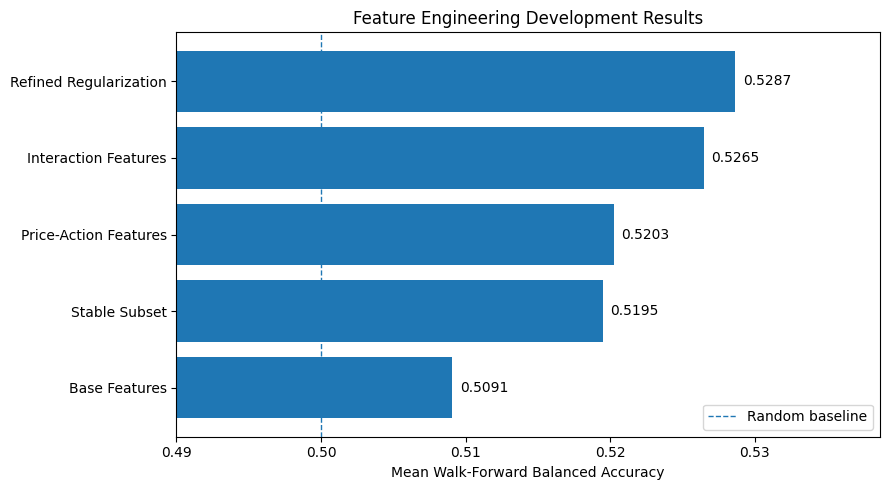

In [ ]:
base_score = feature_set_comparison.loc[
    feature_set_comparison["Feature Set"] == "Base",
    "Mean Balanced Accuracy"
].iloc[0]

price_action_score = feature_set_comparison.loc[
    feature_set_comparison["Feature Set"] == "Base + Price Action",
    "Mean Balanced Accuracy"
].iloc[0]

stable_score = compact_comparison.loc[
    compact_comparison["Feature Set"] == "Stable subset",
    "Mean Balanced Accuracy"
].iloc[0]

refined_score = float(
    base_result["Mean Balanced Accuracy"]
)

interaction_score = float(
    interaction_result["Mean Balanced Accuracy"]
)


feature_progression = pd.DataFrame({
    "Experiment": [
        "Base Features",
        "Price-Action Features",
        "Stable Subset",
        "Refined Regularization",
        "Interaction Features"
    ],
    "Balanced Accuracy": [
        base_score,
        price_action_score,
        stable_score,
        refined_score,
        interaction_score
    ]
})

feature_progression = (
    feature_progression
    .sort_values("Balanced Accuracy")
    .reset_index(drop=True)
)


plt.figure(figsize=(9, 5))

bars = plt.barh(
    feature_progression["Experiment"],
    feature_progression["Balanced Accuracy"]
)

plt.axvline(
    0.50,
    linestyle="--",
    linewidth=1,
    label="Random baseline"
)

plt.xlabel("Mean Walk-Forward Balanced Accuracy")
plt.title("Feature Engineering Development Results")

plt.xlim(
    0.49,
    feature_progression["Balanced Accuracy"].max() + 0.01
)

for bar, value in zip(
    bars,
    feature_progression["Balanced Accuracy"]
):
    plt.text(
        value + 0.0005,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.4f}",
        va="center"
    )

plt.legend()
plt.tight_layout()
plt.show()

### Most Stable Selected Features

The chart highlights features that received non-zero L1 coefficients most consistently across the chronological development folds. Mean absolute coefficients are shown for context, while the fold labels indicate how consistently each feature was retained.

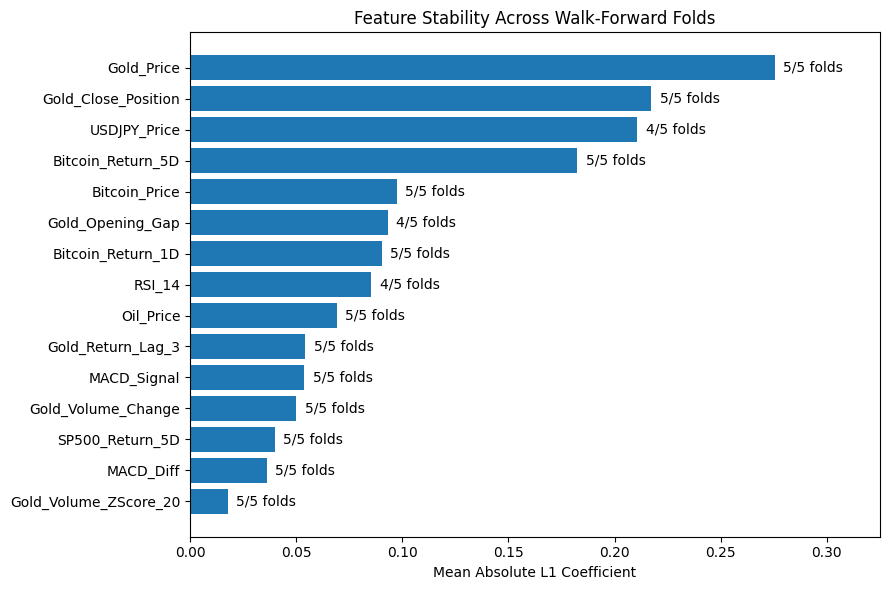

In [ ]:
top_stable_features = (
    feature_stability_df
    .sort_values(
        ["Selected Folds", "Mean Abs Coefficient"],
        ascending=False
    )
    .head(15)
    .sort_values(
        "Mean Abs Coefficient",
        ascending=True
    )
)

plt.figure(figsize=(9, 6))

bars = plt.barh(
    top_stable_features["Feature"],
    top_stable_features["Mean Abs Coefficient"]
)

for bar, folds in zip(
    bars,
    top_stable_features["Selected Folds"]
):
    plt.text(
        bar.get_width() + 0.004,
        bar.get_y() + bar.get_height() / 2,
        f"{int(folds)}/5 folds",
        va="center"
    )

plt.xlabel("Mean Absolute L1 Coefficient")
plt.title("Feature Stability Across Walk-Forward Folds")

plt.margins(x=0.18)
plt.tight_layout()
plt.show()

## 17. Final Model Tuning

The selected 41-feature configuration is refined using only the development period. A narrow search is performed around the strongest L1 regularization region, followed by selection of a single classification threshold from walk-forward out-of-fold predictions.

All model settings are frozen before evaluating the historical holdout period.

In [ ]:
# Fine search around the strongest regularization region
final_c_grid = [
    0.10,
    0.125,
    0.15,
    0.175,
    0.20,
    0.225,
    0.25,
    0.275,
    0.30
]

final_tuning_results = []

for c_value in final_c_grid:

    fold_results = walk_forward_logistic(
        final_development_data,
        final_feature_columns,
        c_value
    )

    final_tuning_results.append({
        "C": c_value,
        "Mean Balanced Accuracy":
            fold_results["Balanced Accuracy"].mean(),
        "Mean ROC AUC":
            fold_results["ROC AUC"].mean()
    })


final_tuning_df = pd.DataFrame(
    final_tuning_results
).sort_values(
    ["Mean Balanced Accuracy", "Mean ROC AUC"],
    ascending=False
).reset_index(drop=True)

best_final_c = float(
    final_tuning_df.iloc[0]["C"]
)

print("Selected C:", best_final_c)

final_tuning_df.round(4)


# Out-of-fold probabilities for threshold selection
time_split = TimeSeriesSplit(
    n_splits=5,
    gap=1
)

oof_probabilities = []
oof_targets = []

for train_idx, val_idx in time_split.split(
    final_development_data
):

    train_fold = final_development_data.iloc[
        train_idx
    ]

    val_fold = final_development_data.iloc[
        val_idx
    ]

    scaler = StandardScaler()

    X_train = scaler.fit_transform(
        train_fold[final_feature_columns]
    )

    X_val = scaler.transform(
        val_fold[final_feature_columns]
    )

    model = LogisticRegression(
        penalty="l1",
        solver="liblinear",
        C=best_final_c,
        max_iter=2000,
        random_state=cfg.seed
    )

    model.fit(
        X_train,
        train_fold["Target"]
    )

    probabilities = model.predict_proba(
        X_val
    )[:, 1]

    oof_probabilities.extend(probabilities)
    oof_targets.extend(
        val_fold["Target"].to_numpy()
    )


oof_probabilities = np.array(
    oof_probabilities
)

oof_targets = np.array(
    oof_targets
)


# Select one threshold from development data
threshold_scores = []

for threshold in np.arange(
    0.35,
    0.66,
    0.01
):
    predictions = (
        oof_probabilities >= threshold
    ).astype(int)

    threshold_scores.append({
        "Threshold": threshold,
        "Balanced Accuracy":
            balanced_accuracy_score(
                oof_targets,
                predictions
            )
    })


final_threshold_df = pd.DataFrame(
    threshold_scores
)

best_threshold_row = final_threshold_df.loc[
    final_threshold_df[
        "Balanced Accuracy"
    ].idxmax()
]

final_threshold = float(
    best_threshold_row["Threshold"]
)

print(
    "Selected threshold:",
    round(final_threshold, 2)
)

print(
    "Development balanced accuracy:",
    round(
        best_threshold_row["Balanced Accuracy"],
        4
    )
)

Selected C: 0.2
Selected threshold: 0.49
Development balanced accuracy: 0.5322


## 18. Historical Holdout Evaluation

The final model configuration is frozen using development data only. The model is then trained on the complete corrected development period and evaluated on the 2022–2024 historical holdout.

Because this time period had been inspected during an earlier version of the project, it is treated as a historical holdout rather than claimed as a completely untouched final test set.

In [ ]:
# Final development and historical holdout sets
final_train = final_development_data.copy()

final_test = (
    price_action_matched[
        price_action_matched["Date"] >= test_start_date
    ]
    .copy()
    .reset_index(drop=True)
)

assert final_train["Date"].max() < final_test["Date"].min()


print(
    "Training period:",
    final_train["Date"].min(),
    "→",
    final_train["Date"].max()
)

print(
    "Holdout period:",
    final_test["Date"].min(),
    "→",
    final_test["Date"].max()
)

print("Training samples:", len(final_train))
print("Holdout samples:", len(final_test))


# Scale from development data only
final_scaler = StandardScaler()

X_final_train = final_scaler.fit_transform(
    final_train[final_feature_columns]
)

X_final_test = final_scaler.transform(
    final_test[final_feature_columns]
)

y_final_train = final_train["Target"]
y_final_test = final_test["Target"]


# Frozen final model
final_model = LogisticRegression(
    penalty="l1",
    solver="liblinear",
    C=best_final_c,
    max_iter=2000,
    random_state=cfg.seed
)

final_model.fit(
    X_final_train,
    y_final_train
)


final_probabilities = final_model.predict_proba(
    X_final_test
)[:, 1]

final_predictions = (
    final_probabilities >= final_threshold
).astype(int)


final_results = evaluate_binary_classifier(
    y_true=y_final_test,
    y_pred=final_predictions,
    y_prob=final_probabilities
)

final_results["Model"] = "L1 Logistic Regression"

pd.DataFrame(
    [final_results]
).round(4)


print(
    "Predicted UP:",
    round(final_predictions.mean() * 100, 1),
    "%"
)

print(
    "Actual UP:",
    round(y_final_test.mean() * 100, 1),
    "%"
)

Training period: 2010-10-25 00:00:00 → 2022-09-19 00:00:00
Holdout period: 2022-09-21 00:00:00 → 2024-10-23 00:00:00
Training samples: 2944
Holdout samples: 523
Predicted UP: 22.2 %
Actual UP: 53.5 %


### Historical Holdout Performance

On the 2022–2024 historical holdout, the final L1 Logistic Regression achieved a balanced accuracy of **55.7%** and a ROC-AUC of **56.6%**.

The model predicted an upward Gold move in only **22.2%** of holdout sessions, compared with an actual UP frequency of **53.5%**. This conservative prediction pattern resulted in relatively high UP precision of **66.4%**, but low recall of **27.5%**.

The result suggests modest directional information rather than reliable standalone trading performance. Because this period had been inspected during an earlier version of the project, it is presented as a historical holdout rather than a completely unseen final test.

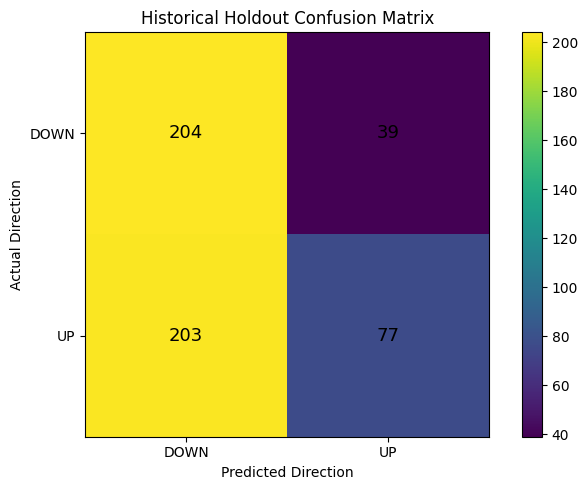

In [ ]:
from sklearn.metrics import confusion_matrix


conf_matrix = confusion_matrix(
    y_final_test,
    final_predictions
)

tn, fp, fn, tp = conf_matrix.ravel()

confusion_df = pd.DataFrame(
    conf_matrix,
    index=["Actual DOWN", "Actual UP"],
    columns=["Predicted DOWN", "Predicted UP"]
)

confusion_df


plt.figure(figsize=(7, 5))

plt.imshow(
    confusion_df,
    interpolation="nearest"
)

plt.title("Historical Holdout Confusion Matrix")
plt.xlabel("Predicted Direction")
plt.ylabel("Actual Direction")

plt.xticks(
    [0, 1],
    ["DOWN", "UP"]
)

plt.yticks(
    [0, 1],
    ["DOWN", "UP"]
)

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            confusion_df.iloc[i, j],
            ha="center",
            va="center",
            fontsize=13
        )

plt.colorbar()
plt.tight_layout()
plt.show()

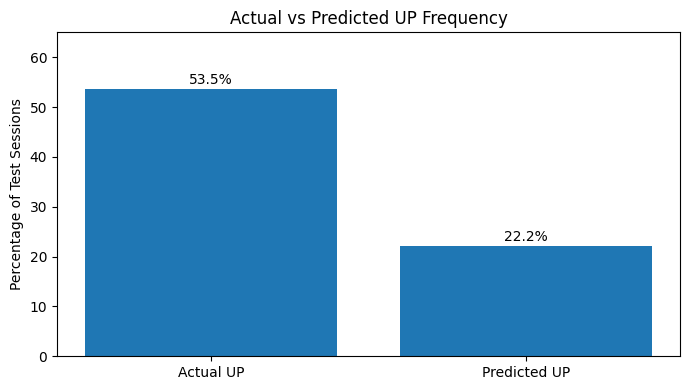

In [ ]:
prediction_summary = pd.DataFrame({
    "Direction": [
        "Actual UP",
        "Predicted UP"
    ],
    "Percentage": [
        y_final_test.mean() * 100,
        final_predictions.mean() * 100
    ]
})


plt.figure(figsize=(7, 4))

bars = plt.bar(
    prediction_summary["Direction"],
    prediction_summary["Percentage"]
)

plt.ylabel("Percentage of Test Sessions")
plt.title("Actual vs Predicted UP Frequency")
plt.ylim(0, 65)


for bar, value in zip(
    bars,
    prediction_summary["Percentage"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 1,
        f"{value:.1f}%",
        ha="center"
    )


plt.tight_layout()
plt.show()

### Probability-Based Holdout Performance

ROC and precision–recall curves evaluate the frozen model using predicted probabilities rather than a single classification threshold. These curves provide a broader view of how well the model separates upward and downward Gold sessions across the historical holdout period.

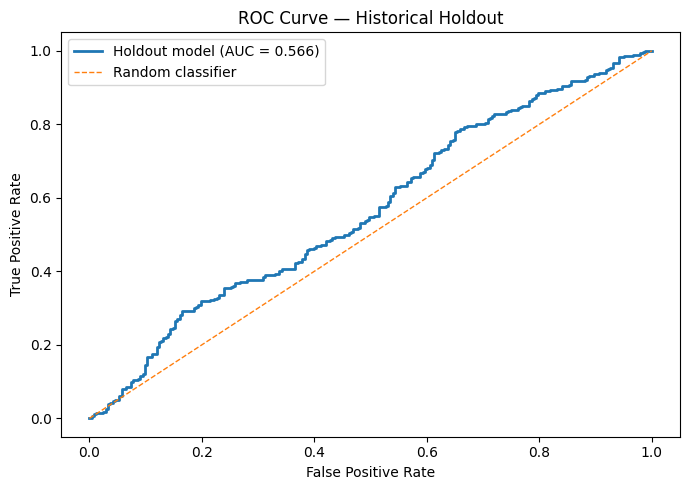

In [ ]:
fpr, tpr, _ = roc_curve(
    y_final_test,
    final_probabilities
)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"Holdout model (AUC = {final_results['ROC_AUC']:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1,
    label="Random classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Historical Holdout")

plt.legend()
plt.tight_layout()
plt.show()

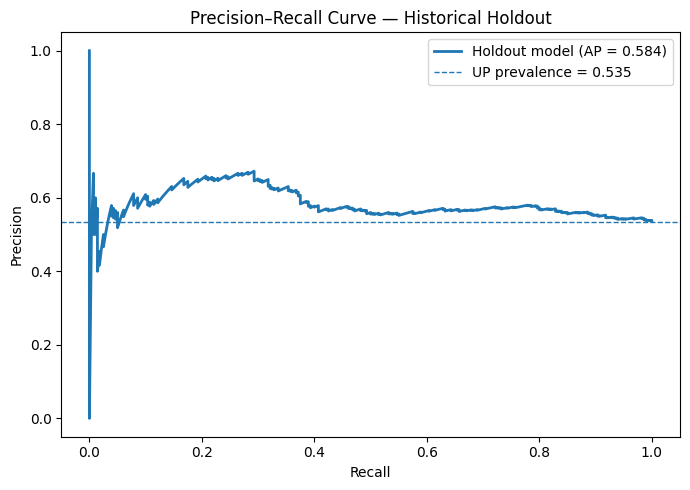

Average precision: 0.5841


In [ ]:
precision_values, recall_values, _ = precision_recall_curve(
    y_final_test,
    final_probabilities
)

average_precision = average_precision_score(
    y_final_test,
    final_probabilities
)

class_baseline = y_final_test.mean()


plt.figure(figsize=(7, 5))

plt.plot(
    recall_values,
    precision_values,
    linewidth=2,
    label=f"Holdout model (AP = {average_precision:.3f})"
)

plt.axhline(
    class_baseline,
    linestyle="--",
    linewidth=1,
    label=f"UP prevalence = {class_baseline:.3f}"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve — Historical Holdout")

plt.legend()
plt.tight_layout()
plt.show()

print(
    "Average precision:",
    round(average_precision, 4)
)

## 19. Final Results and Interpretation

The final configuration was selected using the corrected development-only workflow. Feature selection, regularization tuning and threshold selection were completed before evaluating the 2022–2024 historical holdout.

Because this period had been inspected during an earlier version of the project, the results are presented as a historical holdout evaluation rather than as performance on a completely unseen test set.

In [ ]:
final_summary = pd.DataFrame({
    "Setting": [
        "Model",
        "Features",
        "Regularization",
        "C",
        "Decision Threshold",
        "Development Samples",
        "Holdout Samples",
        "Accuracy",
        "Balanced Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC AUC",
        "Average Precision"
    ],

    "Value": [
        "L1 Logistic Regression",
        len(final_feature_columns),
        "L1",
        best_final_c,
        final_threshold,
        len(final_train),
        len(final_test),
        final_results["Accuracy"],
        final_results["Balanced_Accuracy"],
        final_results["Precision"],
        final_results["Recall"],
        final_results["F1"],
        final_results["ROC_AUC"],
        average_precision
    ]
})

final_summary

,Setting,Value
0,Model,L1 Logistic Regression
1,Features,41
2,Regularization,L1
3,C,0.2
4,Decision Threshold,0.49
5,Development Samples,2944
6,Holdout Samples,523
7,Accuracy,0.537285
8,Balanced Accuracy,0.557253
9,Precision,0.663793


### Interpretation

The final L1-regularized Logistic Regression achieved **55.7% balanced accuracy** and a **56.6% ROC-AUC** on the 2022–2024 historical holdout.

The model produced UP predictions relatively infrequently, classifying approximately **22.2%** of holdout sessions as upward compared with an observed UP frequency of **53.5%**. These UP predictions achieved approximately **66.4% precision**, although recall remained low at **27.5%**.

The feature-engineering experiments showed that additional complexity did not automatically improve performance. Price-action features improved development results relative to the original feature set, while aggressive feature pruning and additional interaction features did not improve the primary validation metric and were therefore rejected.

Overall, the model demonstrates modest directional information rather than a reliable standalone trading strategy. The main value of the project is the complete experimental workflow: cross-market feature construction, chronological validation, leakage control, feature ablation, L1 regularization, feature-stability analysis, threshold selection, and transparent historical evaluation.